# Стабильность регрессионных моделей во времени

**Курсовая работа.** Прогноз количества часов, проведённых пользователем в игре
за следующие 30 дней (`target_hours_next_30d`). Эта величина прямо связана с
рекламным доходом от пользователя: чем дольше играет, тем больше показов
рекламы, тем выше LTV.

**Цель:** изучить стабильность модели во времени, её деградацию на разных
датах и найти компромисс между качеством и стабильностью.
Сравниваем три параметрических семейства: линейная регрессия (Ridge),
градиентный бустинг (LightGBM) и нейросеть (MLPRegressor из sklearn).

**Что в ноутбуке:**
1. Загрузка, EDA (распределение target, дрейф по времени, covariate drift).
2. Split: train (7 первых снэпшотов) + val (4 переходных) + test (7 поздних).
3. **Три явных Baseline-раздела** — Ridge / LightGBM / MLP, каждый показывает
   собственные кривые **val и test** на графиках Spearman / RMSE.
4. Диагностика дрейфа: PSI + adversarial validation + важность признаков.
5. Углублённое исследование линейной модели (5 вариантов).
6. Углублённое исследование LightGBM (7 экспериментов).
7. **Per-model window sweep**: каждая из трёх моделей подбирает СВОЁ
   оптимальное окно для sliding-режима — это ключевое нововведение.
8. Финальное 3-way сравнение на персональных окнах.
9. BASELINE vs EXTENDED наборы признаков.
10. Выводы.

**Главная метрика — Spearman** (ранговая корреляция). Она лучше отражает
практическую цель (ранжирование пользователей по будущему доходу) и устойчива
к выбросам — «китам», которые искажают RMSE. Дополнительно выводим  MAE / R² для полноты.

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
from scipy.stats import spearmanr
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 130
plt.rcParams["axes.grid"] = True

random_state = 42
np.random.seed(random_state)

DATA_PATH = "/Users/dmitrijmitrhin/Desktop/MLGameDev/snapshot_extended_final.parquet"
ART_DIR = "/Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final"
os.makedirs(ART_DIR, exist_ok=True)

H = 30
CAP= H * 24.0
LOG_cap = np.log1p(CAP)


def save_fig(name):
    """Сохраняет график в artifacts_final/ и показывает его в ноутбуке."""
    path = os.path.join(ART_DIR, name)
    plt.tight_layout()
    fig = plt.gcf()
    fig.savefig(path, bbox_inches="tight")
    print(f"  [saved] {path}")
    display(fig)
    plt.close(fig)

## Вспомогательные функции

- `metrics(y, y_pred)` — четыре метрики: MAE, RMSE, R², Spearman.
- `stability_row(name, curves, split)` — сводный показатель по кривой (метрики по snapshot-датам): Spearman_mean, Spearman_std, stability = 1/(1+std) (стабильность), slope`(наклон тренда — скорость деградации), R2_mean, RMSE_mean, MAE_mean.

Параметр `split` фильтрует кривую по подмножеству `'val'` или `'test'`.

In [2]:
def metrics(y, y_pred):
    return {
        "MAE": mean_absolute_error(y, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y, y_pred)),
        "R2": r2_score(y, y_pred),
        "Spearman": spearmanr(y, y_pred).correlation,
    }


def stability_row(name, curves, split=None):
    c = curves if split is None else curves[curves["split"] == split]
    if len(c) == 0:
        return None
    sp = c["Spearman"].dropna().values
    return {
        "model": name,
        "Spearman_mean": sp.mean(),
        "Spearman_std": sp.std(),
        "stability": 1 / (1 + sp.std()),
        "slope": np.polyfit(range(len(sp)), sp, 1)[0] if len(sp) >= 2 else 0.0,
        "R2_mean": c["R2"].dropna().mean(),
        "RMSE_mean": c["RMSE"].dropna().mean(),
        "MAE_mean": c["MAE"].dropna().mean(),
    }

## Подготовка признаков для линейной модели

`prep_X_for_linear(...)` — простая обёртка без `sklearn.Pipeline`. Что делает:

1. **Числовые** → signed `log1p` (если `use_log=True`): сжимает тяжёлые
   распределения, устойчиво к отрицательным значениям;
2. **Низкокардинальные категории** (`device_type`, `connection_type`) →
   one-hot через `pd.get_dummies`;
3. **Высококардинальные** (`country_iso_code`, `app_version_name`) →
   частотное кодирование (заменяем значение на его частоту в train);
4. **Стандартизация** (StandardScaler) — фитим только на train, применяем к test.

Для LightGBM такой препроцессинг не нужен: бустинг работает напрямую с
категориальными признаками (`categorical_feature=...`) и нечувствителен
к шкале числовых.

In [3]:
def prep_X_for_linear(tr, te, num_cols, low_cols, high_cols, use_log=True):
    tr_num = tr[num_cols].astype(np.float32).fillna(0.0).values
    te_num = te[num_cols].astype(np.float32).fillna(0.0).values
    if use_log:
        tr_num = np.sign(tr_num) * np.log1p(np.abs(tr_num))
        te_num = np.sign(te_num) * np.log1p(np.abs(te_num))

    combined_low = pd.concat([tr[low_cols], te[low_cols]], axis=0).astype(str)
    dummies = pd.get_dummies(combined_low, drop_first=False).astype(np.float32)
    tr_low = dummies.iloc[:len(tr)].values
    te_low = dummies.iloc[len(tr):].values

    tr_high_parts, te_high_parts = [], []
    for c in high_cols:
        freq = tr[c].astype(str).value_counts(normalize=True).to_dict()
        tr_high_parts.append(tr[c].astype(str).map(freq).fillna(0.0).values.astype(np.float32))
        te_high_parts.append(te[c].astype(str).map(freq).fillna(0.0).values.astype(np.float32))
    tr_high = np.column_stack(tr_high_parts) if tr_high_parts else np.zeros((len(tr), 0), dtype=np.float32)
    te_high = np.column_stack(te_high_parts) if te_high_parts else np.zeros((len(te), 0), dtype=np.float32)

    X_tr = np.hstack([tr_num, tr_low, tr_high]).astype(np.float32)
    X_te = np.hstack([te_num, te_low, te_high]).astype(np.float32)
    X_tr = np.nan_to_num(X_tr, nan=0.0, posinf=0.0, neginf=0.0)
    X_te = np.nan_to_num(X_te, nan=0.0, posinf=0.0, neginf=0.0)

    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)
    return X_tr, X_te

## Нейросеть: sklearn MLPRegressor

`make_mlp(hidden=(64, 32), max_iter=25, alpha=1e-3)` — конструктор небольшого
`MLPRegressor` со стандартными настройками.

Почему именно sklearn (а не PyTorch):
- На Python 3.14 + macOS у нас наблюдались зависания PyTorch (MPS-deadlock,
  OpenMP-конфликты) после серии операций. sklearn-вариант работает стабильно.
- Архитектура маленькая `(64, 32)`, log-таргет, ReLU, Adam, batch_size=512,
  early stopping. Этого хватает для нашей задачи и существенно проще, чем
  кастомный PyTorch train-loop.

Препроцессинг для MLP — тот же `prep_X_for_linear`, что и для Ridge:
one-hot для низкокардинальных категорий, частотное кодирование для
высококардинальных, signed-log для числовых, потом StandardScaler. Это
позволяет переиспользовать готовый код без отдельного PyTorch-классов.

Для скорости в static-режиме модель кэшируется и обучается один раз на
train (см. `_fit_and_predict_one_date`); потом тот же `m.predict(X_te)`
применяется к каждой eval-дате. Это критично, потому что один fit MLP
на 880 тыс. строк занимает 30–90 с, а нам нужно 11 предсказаний.

In [4]:
def make_mlp(hidden=(64, 32), max_iter=25, alpha=1e-3):
    """Простой конструктор sklearn-MLPRegressor.
    - hidden_layer_sizes=(64, 32) — маленькая сеть, обучается за ~30-60s на 880k строк;
    - alpha=1e-3 — L2-регуляризация;
    - max_iter ограничен — early_stopping=True останавливает раньше;
    - batch_size=auto;
    - solver='adam' — лучший для табличных данных;
    - random_state=42 для воспроизводимости.
    """
    return MLPRegressor(
        hidden_layer_sizes=hidden,
        activation="relu",
        solver="adam",
        alpha=alpha,
        batch_size=512,
        learning_rate_init=1e-3,
        max_iter=max_iter,
        early_stopping=True,
        n_iter_no_change=5,
        validation_fraction=0.1,
        random_state=random_state,
        verbose=False,
    )

## Главный цикл оценки — `temporal_eval`

Функция, которая обходит snapshot-даты и для каждой:
1. Готовит train (по `mode='static'` — всё до `train_end`; по `'sliding'` —
   окно длины `train_win_days` непосредственно перед `date - purge`);
2. Готовит test = одна snapshot-дата;
3. Подготавливает X в зависимости от `model_kind`:
   - `lgbm`: категории как `category` dtype, LightGBM обрабатывает нативно;
   - `linear` / `ridge`: через `prep_X_for_linear`;
   - `mlp`: через `TabularPreprocessor` + PyTorch.
4. Обучает модель, предсказывает, и потом образает в диапазоне `[0, сap]`;
5. Считает метрики `metrics(y, pred)`, выводит результаты.

Колонка `split` в результате помечает каждую строку как `val` или `test`.

In [5]:
def _fit_and_predict_one_date(df, tr_mask, te, num_cols, low_cols, high_cols, model_kind,
                              log_target, use_log_num, lgb_params, alpha,
                              mlp_hidden, mlp_epochs, _cache=None):
    tr = df[tr_mask]

    y_train = tr["target_hours_next_30d"].values
    y_test = te["target_hours_next_30d"].values

    cached = _cache is not None and _cache.get("model") is not None

    if model_kind == "lgbm":
        feat_cols = num_cols + low_cols + high_cols

        X_train = tr[feat_cols].copy()
        X_test = te[feat_cols].copy()

        for c in low_cols + high_cols:
            X_train[c] = X_train[c].astype("category")
            X_test[c] = X_test[c].astype("category")

        if cached:
            m = _cache["model"]
        else:
            y_fit = np.log1p(np.clip(y_train, 0, None)) if log_target else y_train

            m = lgb.LGBMRegressor(**(lgb_params or {}))
            m.fit(
                X_train,
                y_fit,
                categorical_feature=low_cols + high_cols
            )

    elif model_kind in ("linear", "ridge"):
        X_train, X_test = prep_X_for_linear(
            tr, te,
            num_cols, low_cols, high_cols,
            use_log=use_log_num
        )

        if cached:
            m = _cache["model"]
        else:
            y_fit = np.log1p(np.clip(y_train, 0, None)) if log_target else y_train

            if model_kind == "linear":
                m = LinearRegression()
            else:
                m = Ridge(alpha=alpha)

            m.fit(X_train, y_fit)

    elif model_kind == "mlp":
        X_train, X_test = prep_X_for_linear(
            tr, te,
            num_cols, low_cols, high_cols,
            use_log=True
        )

        if cached:
            m = _cache["model"]
        else:
            m = make_mlp(
                hidden=mlp_hidden,
                max_iter=mlp_epochs
            )

            m.fit(
                X_train,
                np.log1p(np.clip(y_train, 0, None))
            )

    else:
        raise ValueError(f"Unknown model_kind: {model_kind}")

    if not cached and _cache is not None:
        _cache["model"] = m

    p = m.predict(X_test)

    if log_target or model_kind == "mlp":
        p = np.expm1(np.clip(p, None, LOG_cap))

    return np.clip(p, 0, CAP), y_test


def temporal_eval(df, num_cols, low_cols, high_cols, model_kind,
                  train_end, mode="static", train_win_days=42,
                  val_dates=None, test_dates=None,
                  log_target=True, use_log_num=True,
                  lgb_params=None, alpha=3.0,
                  mlp_hidden=(64, 32), mlp_epochs=25,
                  verbose=False):

    purge = pd.Timedelta(days=H)

    val_dates = val_dates or []
    test_dates = test_dates or []

    eval_dates = [(d, "val") for d in val_dates] + [(d, "test") for d in test_dates]

    static_cache = {} if mode == "static" else None

    if mode == "static":
        static_train_mask = df["snapshot_date"] <= train_end
    else:
        static_train_mask = None

    rows = []

    for td, split_name in eval_dates:
        td = pd.Timestamp(td)

        if mode == "static":
            tr_mask = static_train_mask
        else:
            lo = td - purge - pd.Timedelta(days=train_win_days)
            hi = td - purge

            tr_mask = (df["snapshot_date"] > lo) & (df["snapshot_date"] <= hi)

        te = df[df["snapshot_date"] == td]

        if tr_mask.sum() < 2000 or len(te) < 200:
            continue

        p, y_test = _fit_and_predict_one_date(
            df, tr_mask, te,
            num_cols, low_cols, high_cols,
            model_kind,
            log_target, use_log_num,
            lgb_params, alpha,
            mlp_hidden, mlp_epochs,
            _cache=static_cache
        )

        p = np.nan_to_num(
            p,
            nan=0.0,
            posinf=CAP,
            neginf=0.0
        )

        row = {
            "test_date": td,
            "split": split_name
        }

        row.update(metrics(y_test, p))

        row["n_train"] = int(tr_mask.sum())
        row["n_test"] = len(te)

        rows.append(row)

        if verbose:
            print(
                f"{model_kind} | {split_name} | {td.date()} | "
                f"n_train={int(tr_mask.sum())} | n_test={len(te)}"
            )

    return pd.DataFrame(rows)

## Функции для графиков

- `plot_val_test_curve(curve, metric)` — одна модель, метрика по дате с
  разделением val-сегмента (пунктир, оранжевый) и test-сегмента (сплошной,
  синий).
- `plot_three_curves(curves_dict, metric)` — несколько моделей на одних осях.
  Для каждой — val пунктиром, test сплошной, цвета из палитры tab10.
- `plot_exp_vs_baseline(exp_name, exp_curve, base_curve)` — per-experiment
  график для каждой стабилизирующей техники LightGBM: 3 панели
  (Spearman / RMSE / MAE) с заливкой зелёным = эксперимент лучше baseline,
  красным = хуже. В заголовке выносим дельты `ΔSpearman_mean`,
  `ΔSpearman_std`, `ΔRMSE_mean`.

In [6]:
def plot_val_test_curve(curve, metric="Spearman", title="", baseline_curve=None):
    fig, ax = plt.subplots(figsize=(11, 4.5))
    val_part = curve[curve["split"] == "val"].sort_values("test_date")
    test_part = curve[curve["split"] == "test"].sort_values("test_date")

    if baseline_curve is not None:
        base_val = baseline_curve[baseline_curve["split"] == "val"].sort_values("test_date")
        base_test = baseline_curve[baseline_curve["split"] == "test"].sort_values("test_date")
        ax.plot(base_val["test_date"], base_val[metric], "o:", color="grey", alpha=0.6, label="baseline val")
        ax.plot(base_test["test_date"], base_test[metric], "o-", color="grey", alpha=0.7, label="baseline test")

    if len(val_part):
        ax.plot(val_part["test_date"], val_part[metric], "s--", color="tab:orange",
                linewidth=2, label="val (зона purge)")
        ax.axvspan(val_part["test_date"].min(), val_part["test_date"].max(), alpha=0.06, color="orange")
    if len(test_part):
        ax.plot(test_part["test_date"], test_part[metric], "o-", color="tab:blue",
                linewidth=2, label="test")

    ax.set_title(title or f"{metric} по snapshot-датам (val + test)")
    ax.set_ylabel(metric)
    ax.set_xlabel("snapshot_date")
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", rotation=45)


def plot_three_curves(curves_dict, metric="Spearman", title=""):
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = plt.cm.tab10.colors
    for i, (name, c) in enumerate(curves_dict.items()):
        col = colors[i % 10]
        val_part = c[c["split"] == "val"].sort_values("test_date")
        test_part = c[c["split"] == "test"].sort_values("test_date")
        ax.plot(val_part["test_date"], val_part[metric], "s--", color=col, alpha=0.6)
        ax.plot(test_part["test_date"], test_part[metric], "o-", color=col, linewidth=2, label=name)
    ax.set_title(title or f"{metric} — сравнение моделей")
    ax.set_ylabel(metric)
    ax.set_xlabel("snapshot_date")
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", rotation=45)


def plot_exp_vs_baseline(exp_name, exp_curve, base_curve, save_name=None):
    exp_test = exp_curve[exp_curve["split"] == "test"].sort_values("test_date")
    base_test = base_curve[base_curve["split"] == "test"].sort_values("test_date")
    sp_imp = (exp_test["Spearman"].mean() - base_test["Spearman"].mean()) * 100
    sp_std_imp = (exp_test["Spearman"].std() - base_test["Spearman"].std()) * 100
    rm_imp = (exp_test["RMSE"].mean() / base_test["RMSE"].mean() - 1) * 100

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for ax, metric, lower_is_better in zip(axes, ["Spearman", "RMSE", "MAE"], [False, True, True]):
        x = base_test["test_date"].values
        b = base_test[metric].values
        e = exp_test[metric].values
        ax.plot(x, b, "o-", color="black", linewidth=2, label="baseline")
        ax.plot(x, e, "s-", color="tab:red", linewidth=2, label=exp_name)
        improved = e <= b if lower_is_better else e >= b
        ax.fill_between(x, b, e, where=improved, alpha=0.25, color="seagreen")
        ax.fill_between(x, b, e, where=~improved, alpha=0.25, color="firebrick")
        ax.set_title(metric)
        ax.set_xlabel("test_date")
        ax.tick_params(axis="x", rotation=45)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.4)
    fig.suptitle(
        f"«{exp_name}» vs baseline:  ΔSpearman_mean = {sp_imp:+.1f} п.п.,  "
        f"ΔSpearman_std = {sp_std_imp:+.1f} п.п.,  ΔRMSE_mean = {rm_imp:+.1f}%",
        y=1.04, fontsize=12)
    if save_name:
        save_fig(save_name)

## 1. Загрузка данных

`snapshot_extended_final.parquet` — 1.9 млн строк × 146 колонок. Каждая строка =
один пользователь в одну snapshot-дату. Признаки в строке агрегированы по
предыдущим окнам (1/3/7/14/30 дней), таргет — суммарные часы в следующие
30 дней после snapshot-даты.

Сразу:
- кастуем `float64 → float32` и `int64 → int32` (память на 1.9 М строк
  падает примерно вдвое);
- удаляем `playtime_minutes_*` (идеально коллинеарны с `playtime_hours_*` —
  вредны для линейной модели);
- удаляем `os_name` (у всех `android`, нулевая информативность).

In [7]:
df = pd.read_parquet(DATA_PATH)
df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])

for c in df.select_dtypes("float64").columns:
    df[c] = df[c].astype(np.float32)
for c in df.select_dtypes("int64").columns:
    df[c] = df[c].astype(np.int32)

drop_cols = [c for c in df.columns if c.startswith("playtime_minutes_")] + ["os_name"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

dates_all = np.array(sorted(df["snapshot_date"].unique()))
print(f"shape: {df.shape}  |  память: {df.memory_usage(deep=True).sum() / 1e6:.1f} МБ")
print(f"снэпшотов: {len(dates_all)}  |  период: {pd.Timestamp(dates_all[0]).date()} → {pd.Timestamp(dates_all[-1]).date()}")

shape: (1902781, 140)  |  память: 922.0 МБ
снэпшотов: 18  |  период: 2025-12-01 → 2026-03-30


## 2. Группы признаков

Разбиваем колонки по четырём группам:

- **`ID_COLS`** — `user_id`, `snapshot_date`. Не идут в модель.
- **`CAT_LOW`** (низкокардинальные) — `device_type`, `connection_type`.
  Можно делать one-hot.
- **`CAT_HIGH`** (высококардинальные) — `country_iso_code`,
  `app_version_name`. one-hot был бы взрывным; используем частотное
  кодирование (для линейной) или категории в LightGBM/MLP.
- **Числовые** — две версии набора:
  - `BASELINE_NUM` — ~21 столбец: playtime, sessions, events, активные дни;
  - `EXTENDED_NUM` — `BASELINE` + блок `ml_init_*`/`ml_snap_*` +
    `was_nan`-флаги (~140 колонок).

Эти два набора сравниваются в Части 17.

In [8]:
TARGET = "target_hours_next_30d"
ID_COLS = ["user_id", "snapshot_date"]
CAT_LOW = ["device_type", "connection_type"]
CAT_HIGH = ["country_iso_code", "app_version_name"]
WASNAN = [c for c in df.columns if c.endswith("_was_nan")]

BASELINE_NUM = [
    "playtime_hours_1d", "playtime_hours_3d", "playtime_hours_7d",
    "playtime_hours_14d", "playtime_hours_30d",
    "events_count_7d", "events_count_30d",
    "sessions_count_7d", "sessions_count_30d",
    "ads_count_7d", "ads_count_30d",
    "reward_count_7d", "reward_count_30d",
    "training_count_7d", "training_count_30d",
    "ml_event_count_7d", "ml_event_count_30d",
    "active_days_7d", "active_days_30d", "CAPped_days_30d",
    "days_since_first_seen",
]
BASELINE_NUM = [c for c in BASELINE_NUM if c in df.columns]

NUMERIC_ALL = [c for c in df.columns
               if c not in ID_COLS + [TARGET] + CAT_LOW + CAT_HIGH + WASNAN
               and pd.api.types.is_numeric_dtype(df[c])]
ML_EXT_NUM = [c for c in NUMERIC_ALL if c not in BASELINE_NUM]
EXTENDED_NUM = BASELINE_NUM + ML_EXT_NUM + WASNAN

FEATS = {
    "BASELINE": dict(num=BASELINE_NUM, low=CAT_LOW, high=CAT_HIGH),
    "EXTENDED": dict(num=EXTENDED_NUM, low=CAT_LOW, high=CAT_HIGH),
}
print(f"BASELINE: числовых {len(BASELINE_NUM)}, кат {len(CAT_LOW + CAT_HIGH)}")
print(f"EXTENDED: числовых {len(EXTENDED_NUM)} (в т.ч. was_nan: {len(WASNAN)}), кат {len(CAT_LOW + CAT_HIGH)}")

BASELINE: числовых 20, кат 4
EXTENDED: числовых 133 (в т.ч. was_nan: 45), кат 4


## 3. EDA — распределение target

Распределение `target_hours_next_30d` сильно скошенное:
- ~90 % значений = 0 (пользователь не возвращается в течение 30 дней);
- максимум — 720 часов (физический потолок: 30 дней × 24 ч);
- редкие «киты» с десятками-сотнями часов формируют тяжёлый хвост.

На log-шкале распределение активных пользователей почти нормальное — отсюда
мотивация тренировать модели на `log1p(target)` и обратно через `expm1` с
клипом.

EDA — РАСПРЕДЕЛЕНИЕ ТАРГЕТА
count    1902781.000
mean           0.263
std            2.289
min            0.000
50%            0.000
90%            0.000
99%            6.850
max          317.450
Доля нулей: 90.5%
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/eda_target_distribution.png


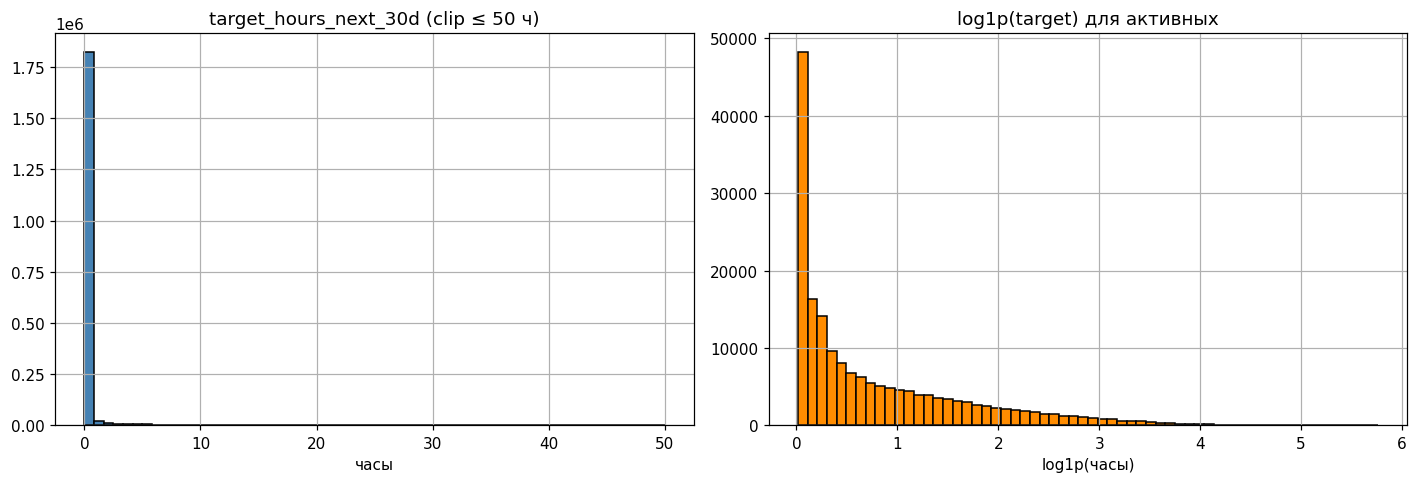

In [9]:
print("EDA — РАСПРЕДЕЛЕНИЕ ТАРГЕТА")
print(df[TARGET].describe(percentiles=[0.5, 0.9, 0.99]).round(3).to_string())
print(f"Доля нулей: {(df[TARGET] == 0).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df[TARGET].clip(0, 50), bins=60, color="steelblue", edgecolor="black")
axes[0].set_title("target_hours_next_30d (clip ≤ 50 ч)")
axes[0].set_xlabel("часы")
pos = df.loc[df[TARGET] > 0, TARGET]
axes[1].hist(np.log1p(pos), bins=60, color="darkorange", edgecolor="black")
axes[1].set_title("log1p(target) для активных")
axes[1].set_xlabel("log1p(часы)")
save_fig("eda_target_distribution.png")

## 4. EDA — дрейф target и доли активных по неделям

Этот двух-осевой график из ноутбука по нейросети — самый компактный визуальный
индикатор `concept drift`:

- **Левая (оранжевая) ось** — средний `target` по snapshot-дате. Если ползёт —
  пользователи в среднем стали играть больше/меньше за тот же горизонт.
- **Правая (зелёная) ось** — доля пользователей с `target > 0` (т.е.
  «активность» — кто вообще вернулся).

Когда обе оси меняются согласованно — это масштабирующая нестабильность
(пропорция активных меняется). Когда расходятся — меняется и состав активных,
и сколько играют те, кто играет.

Под графиком — отдельная гистограмма количества пользователей в каждой
snapshot-дате (для контекста).

EDA — ДРЕЙФ TARGET И ДОЛИ АКТИВНЫХ ВО ВРЕМЕНИ
               n_users  target_mean  active_share
snapshot_date                                    
2025-12-01       94259        0.299         0.111
2025-12-08      108795        0.275         0.106
2025-12-15      131619        0.251         0.104
2025-12-22      135297        0.267         0.112
2025-12-29      141372        0.269         0.096
2026-01-05      143575        0.252         0.088
2026-01-12      131833        0.237         0.082
2026-01-19      130640        0.261         0.091
2026-01-26      121595        0.256         0.089
2026-02-02      107334        0.269         0.093
2026-02-09       99515        0.277         0.093
2026-02-16       91597        0.273         0.092
2026-02-23       84538        0.298         0.100
2026-03-02       83393        0.285         0.099
2026-03-09       80805        0.250         0.093
2026-03-16       78467        0.244         0.088
2026-03-23       72514        0.230         0.083
2026

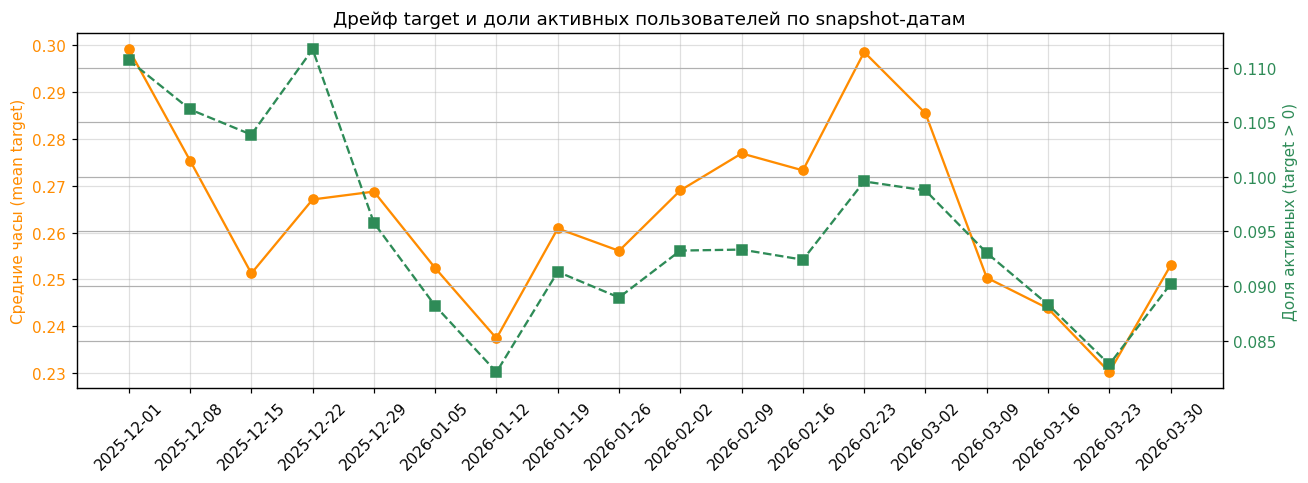

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/eda_n_users.png


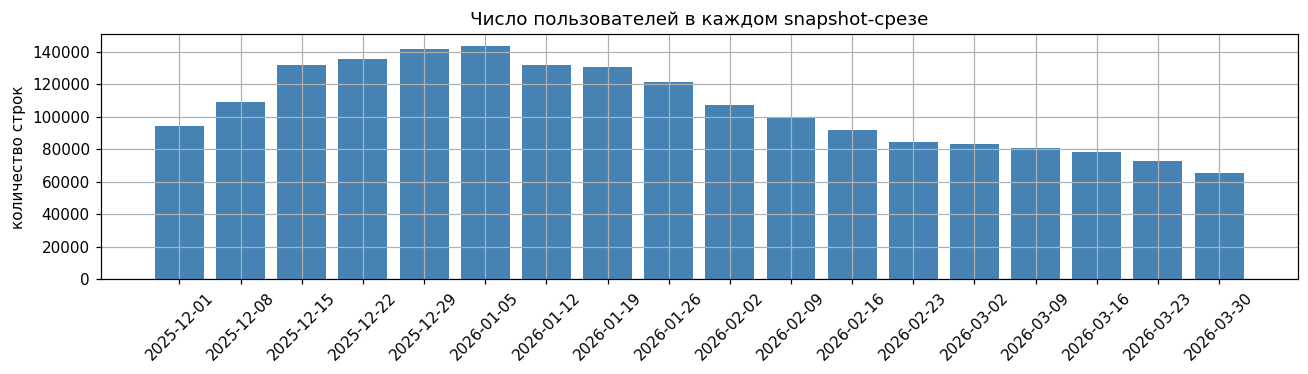

In [10]:
print("EDA — ДРЕЙФ TARGET И ДОЛИ АКТИВНЫХ ВО ВРЕМЕНИ")
date_stats = df.groupby("snapshot_date").agg(
    n_users=("user_id", "size"),
    target_mean=(TARGET, "mean"),
    active_share=(TARGET, lambda x: (x > 0).mean()),
)
print(date_stats.round(3))
date_stats.to_csv(os.path.join(ART_DIR, "eda_date_stats.csv"))

labels = [d.strftime("%Y-%m-%d") for d in date_stats.index]
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(labels, date_stats["target_mean"].values, "o-", color="darkorange", label="mean target")
ax.set_ylabel("Средние часы (mean target)", color="darkorange")
ax.tick_params(axis="y", labelcolor="darkorange")
ax.tick_params(axis="x", rotation=45)
ax2 = ax.twinx()
ax2.plot(labels, date_stats["active_share"].values, "s--", color="seagreen", label="share active")
ax2.set_ylabel("Доля активных (target > 0)", color="seagreen")
ax2.tick_params(axis="y", labelcolor="seagreen")
ax.set_title("Дрейф target и доли активных пользователей по snapshot-датам")
ax.grid(alpha=0.4)
save_fig("eda_target_and_active_drift.png")

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(labels, date_stats["n_users"], color="steelblue")
ax.set_title("Число пользователей в каждом snapshot-срезе")
ax.set_ylabel("количество строк")
ax.tick_params(axis="x", rotation=45)
save_fig("eda_n_users.png")

## 5. EDA — covariate drift по версиям и странам

Главный практический источник дрейфа в нашей задаче — **смена версии
приложения**. За 4 месяца датасета доминирующая версия меняется несколько
раз (выкаты новых билдов). Stackplot долей версий показывает это явно.

География (топ-5 стран) обычно стабильнее, но небольшой сдвиг по странам
тоже виден.

Эти факты явно отразятся в PSI (Часть 11) и adversarial validation
(Часть 12).

EDA — COVARIATE DRIFT (версии и страны)
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/eda_covariate_drift.png


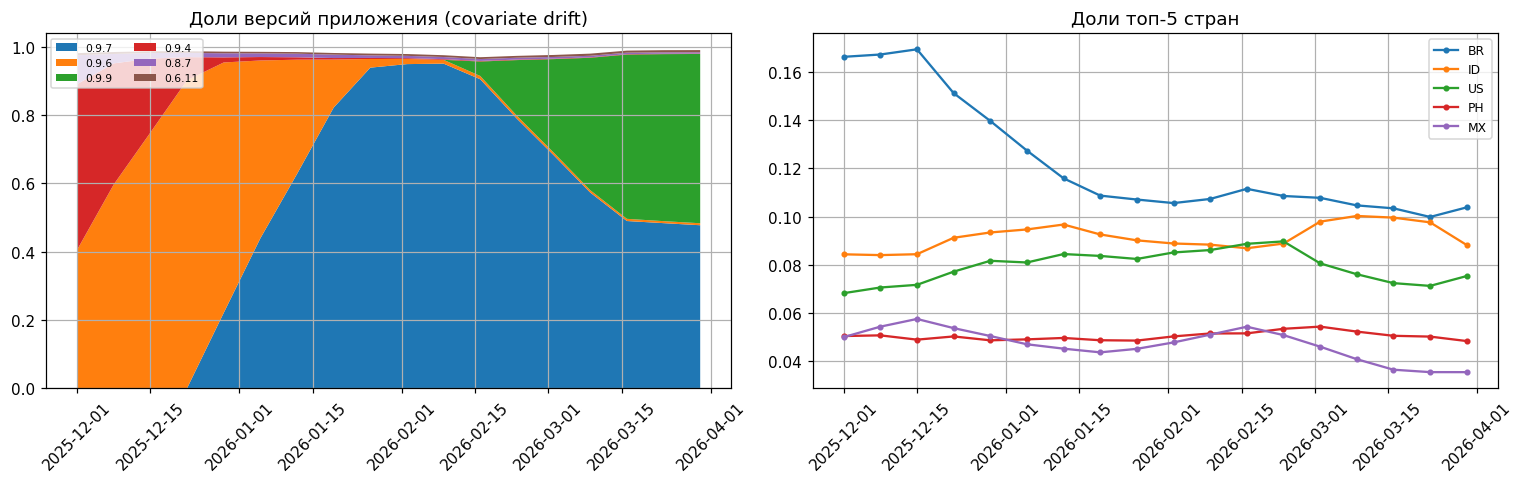

In [11]:
print("EDA — COVARIATE DRIFT (версии и страны)")


def share_over_time(col, top_k=6):
    top = df[col].value_counts().head(top_k).index
    piv = df.groupby(["snapshot_date", col]).size().unstack(fill_value=0)
    piv = piv.div(piv.sum(axis=1), axis=0)
    return piv[top]


fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sv = share_over_time("app_version_name", 6)
axes[0].stackplot(sv.index, sv.T.values, labels=sv.columns)
axes[0].set_title("Доли версий приложения (covariate drift)")
axes[0].legend(loc="upper left", fontsize=7, ncol=2)
axes[0].tick_params(axis="x", rotation=45)
sc = share_over_time("country_iso_code", 5)
for c in sc.columns:
    axes[1].plot(sc.index, sc[c], marker=".", label=c)
axes[1].set_title("Доли топ-5 стран")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=45)
save_fig("eda_covariate_drift.png")

## 6. Split train / val / test

Делим строго по `snapshot_date`. Конфигурация:

- **train** — первые 7 снэпшотов (`dates[0..6]`, 2025-12-01 → 2026-01-12);
- **val** — 4 снэпшота в зоне purge (2026-01-19 → 2026-02-09);
- **test** — 7 поздних снэпшотов (2026-02-16 → 2026-03-30).

**Что такое val в этом контексте.** Это переходная зона между train и
«чистым» test. Между `train_end` и этими датами проходит < 30 дней,
поэтому окна target частично пересекаются с train (target = next 30 days
после snapshot). Значит, метрики на val чуть оптимистично смещены —
о чём мы помним при интерпретации.

**Назначение val** — показывать на графиках Spearman / RMSE деградацию
сразу после train (val) и затем за зоной purge (test). Визуально видно
эффект «переходной зоны».

In [12]:
print("SPLIT TRAIN / VAL / TEST")
N_TRAIN_SNAPS = 6
train_end = pd.Timestamp(dates_all[N_TRAIN_SNAPS])
purge_threshold = train_end + pd.Timedelta(days=H)

train_dates = [pd.Timestamp(d) for d in dates_all[: N_TRAIN_SNAPS + 1]]
val_dates = [pd.Timestamp(d) for d in dates_all if train_end < pd.Timestamp(d) <= purge_threshold]
test_dates = [pd.Timestamp(d) for d in dates_all if pd.Timestamp(d) > purge_threshold]

print(f"train_end = {train_end.date()}  |  purge = {H} дней")
print(f"train ({len(train_dates)}): {[d.date() for d in train_dates]}")
print(f"val   ({len(val_dates)}): {[d.date() for d in val_dates]}  (зона purge)")
print(f"test  ({len(test_dates)}): {[d.date() for d in test_dates]}")

SPLIT TRAIN / VAL / TEST
train_end = 2026-01-12  |  purge = 30 дней
train (7): [datetime.date(2025, 12, 1), datetime.date(2025, 12, 8), datetime.date(2025, 12, 15), datetime.date(2025, 12, 22), datetime.date(2025, 12, 29), datetime.date(2026, 1, 5), datetime.date(2026, 1, 12)]
val   (4): [datetime.date(2026, 1, 19), datetime.date(2026, 1, 26), datetime.date(2026, 2, 2), datetime.date(2026, 2, 9)]  (зона purge)
test  (7): [datetime.date(2026, 2, 16), datetime.date(2026, 2, 23), datetime.date(2026, 3, 2), datetime.date(2026, 3, 9), datetime.date(2026, 3, 16), datetime.date(2026, 3, 23), datetime.date(2026, 3, 30)]


## Базовая конфигурация LightGBM (LGB_BASE)

Стандартный «kaggle-baseline»-набор параметров, описанный в нескольких
независимых источниках (например, [гайд Leonie Monigatti](https://www.leoniemonigatti.com/blog/lightgbm-hyperparameters.html)
и [официальная документация LightGBM](https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html)):

- `learning_rate=0.05` — умеренный темп (kaggle-стандарт);
- `n_estimators=300` — лимит сверху;
- `num_leaves=63` (≈ 2⁶−1, эффективная глубина 6);
- `min_data_in_leaf=200` — защита от переобучения на 1.3 М строк
  (рекомендация: «сотни-тысячи для больших датасетов»);
- `feature_fraction=0.9`, `bagging_fraction=0.9, bagging_freq=1` — лёгкая
  стохастика (точное совпадение с гайдом).

Конфигурация не подобрана через grid search — это сознательный выбор:
baseline должен быть «разумным», а не «переоптимизированным», иначе
стабилизирующие приёмы сравнивались бы с искусственно сильной моделью.

In [13]:
lgb_base = dict(
    objective="regression", metric="rmse",
    learning_rate=0.05, n_estimators=300,
    num_leaves=63, min_data_in_leaf=200,
    feature_fraction=0.9, bagging_fraction=0.9, bagging_freq=1,
    random_state=random_state, n_jobs=-1, verbose=-1,
)
cfg = FEATS["EXTENDED"]

## 7. Baseline — Ridge log static

Линейная модель с L2-регуляризацией (`alpha=3.0`) на EXTENDED-наборе,
с `log1p`-преобразованием числовых признаков и таргета.

Это — отправная точка для всего блока «линейная модель»: 5 вариантов
deep-dive (Часть 13) тренируются именно поверх этой схемы.

На графиках — две кривые (val и test) одной моделью, чтобы было видно
переход качества через purge-зону.

BASELINE — RIDGE log (static, EXTENDED)
ridge | val | 2026-01-19 | n_train=886750 | n_test=130640
ridge | val | 2026-01-26 | n_train=886750 | n_test=121595
ridge | val | 2026-02-02 | n_train=886750 | n_test=107334
ridge | val | 2026-02-09 | n_train=886750 | n_test=99515
ridge | test | 2026-02-16 | n_train=886750 | n_test=91597
ridge | test | 2026-02-23 | n_train=886750 | n_test=84538
ridge | test | 2026-03-02 | n_train=886750 | n_test=83393
ridge | test | 2026-03-09 | n_train=886750 | n_test=80805
ridge | test | 2026-03-16 | n_train=886750 | n_test=78467
ridge | test | 2026-03-23 | n_train=886750 | n_test=72514
ridge | test | 2026-03-30 | n_train=886750 | n_test=65633

[Ridge] заняло 33.4s

Ridge сводка по val: {'model': 'Ridge val', 'Spearman_mean': np.float64(0.35255186263618377), 'Spearman_std': np.float64(0.007285747368456162), 'stability': np.float64(0.9927669508007134), 'slope': np.float64(0.0052824840788583795), 'R2_mean': np.float64(0.1952132315906571), 'RMSE_mean': np.float64(

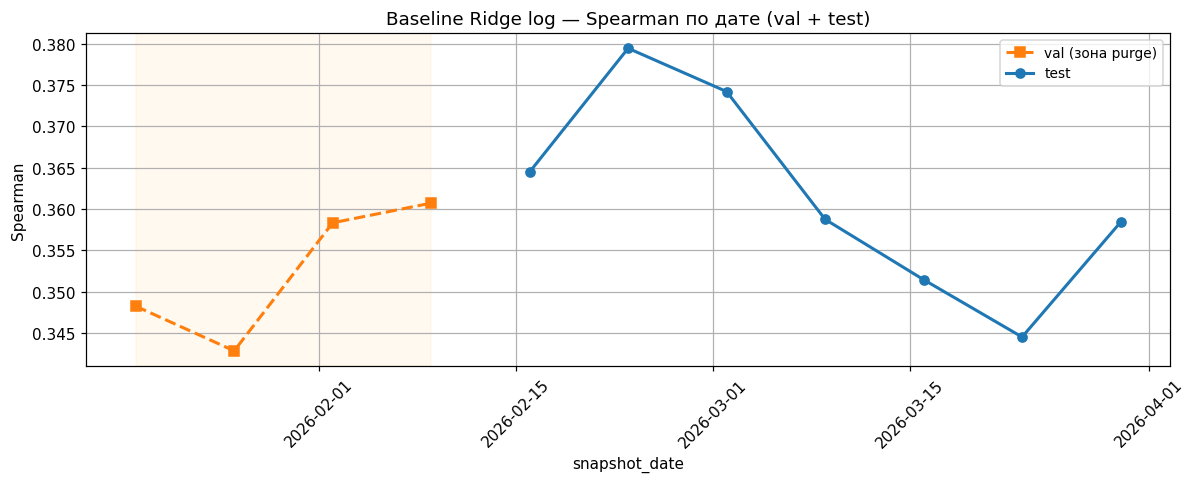

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/baseline_ridge_rmse.png


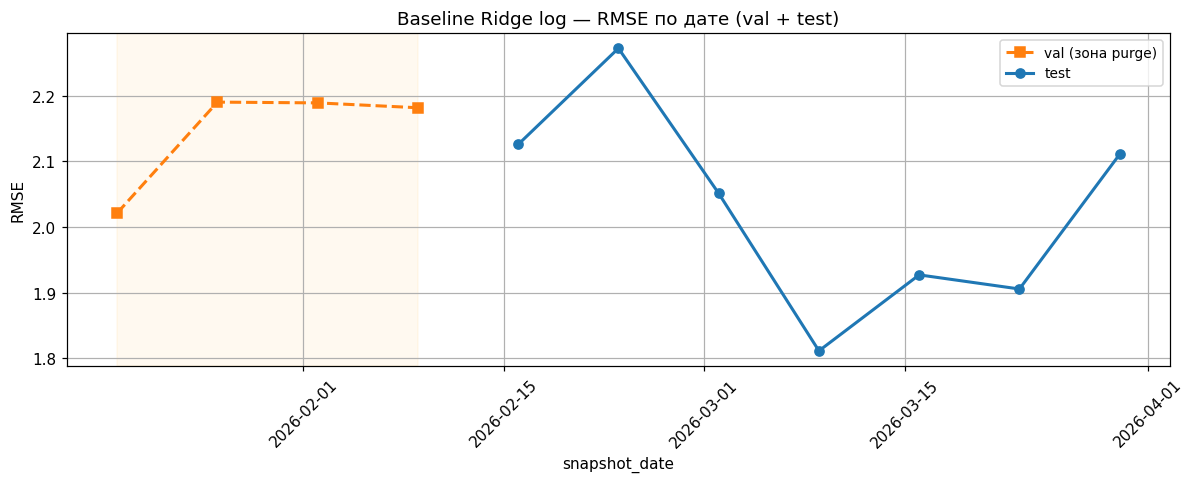

In [14]:
print("BASELINE — RIDGE log (static, EXTENDED)")
t0 = time.time()
base_ridge = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"],
    model_kind="ridge", train_end=train_end, mode="static",
    val_dates=val_dates, test_dates=test_dates,
    log_target=True, use_log_num=True, alpha=3.0, verbose=True,
)
print(f"\n[Ridge] заняло {time.time()-t0:.1f}s")
base_ridge.to_csv(os.path.join(ART_DIR, "baseline_ridge.csv"), index=False)
print("\nRidge сводка по val:", stability_row("Ridge val", base_ridge, "val"))
print("Ridge сводка по test:", stability_row("Ridge test", base_ridge, "test"))

plot_val_test_curve(base_ridge, "Spearman", "Baseline Ridge log — Spearman по дате (val + test)")
save_fig("baseline_ridge_spearman.png")
plot_val_test_curve(base_ridge, "RMSE", "Baseline Ridge log — RMSE по дате (val + test)")
save_fig("baseline_ridge_rmse.png")

## 8. Baseline — LightGBM static (log target)
**Скорость.** На 880 тыс. строк один fit занимает ~15-20 секунд. Static-кэш
делает обучение модели заметно быстрее.

lgbm | val | 2026-01-19 | n_train=886750 | n_test=130640
lgbm | val | 2026-01-26 | n_train=886750 | n_test=121595
lgbm | val | 2026-02-02 | n_train=886750 | n_test=107334
lgbm | val | 2026-02-09 | n_train=886750 | n_test=99515
lgbm | test | 2026-02-16 | n_train=886750 | n_test=91597
lgbm | test | 2026-02-23 | n_train=886750 | n_test=84538
lgbm | test | 2026-03-02 | n_train=886750 | n_test=83393
lgbm | test | 2026-03-09 | n_train=886750 | n_test=80805
lgbm | test | 2026-03-16 | n_train=886750 | n_test=78467
lgbm | test | 2026-03-23 | n_train=886750 | n_test=72514
lgbm | test | 2026-03-30 | n_train=886750 | n_test=65633

[LGBM] занял 16.4s
метрик по val: {'model': 'LGBM val', 'Spearman_mean': np.float64(0.3731996581469902), 'Spearman_std': np.float64(0.005059629051304679), 'stability': np.float64(0.9949658419211598), 'slope': np.float64(0.001703560480750927), 'R2_mean': np.float64(0.30165512993972954), 'RMSE_mean': np.float64(1.99808118728341), 'MAE_mean': np.float64(0.25169638524667926)

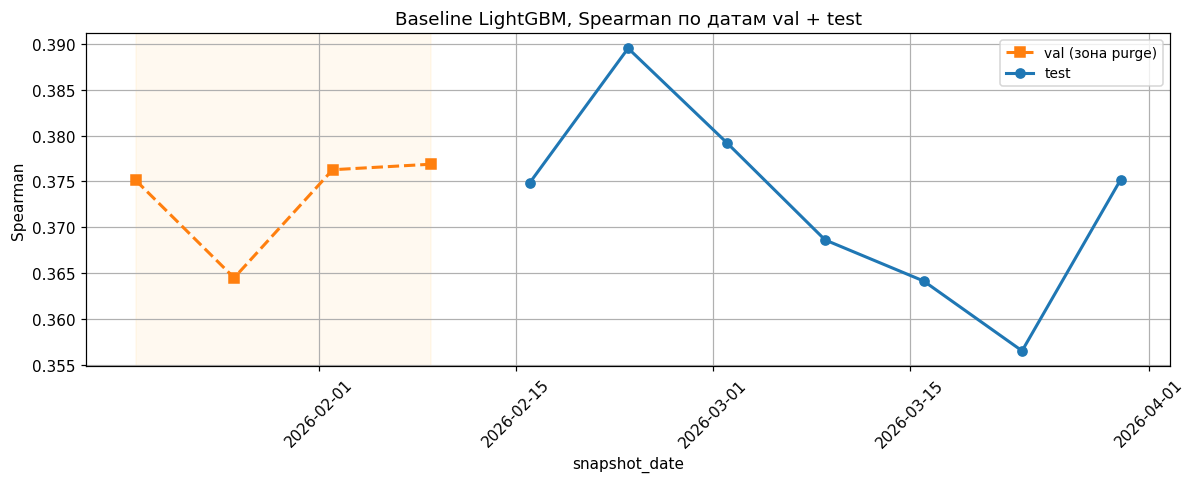

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/baseline_lgbm_rmse.png


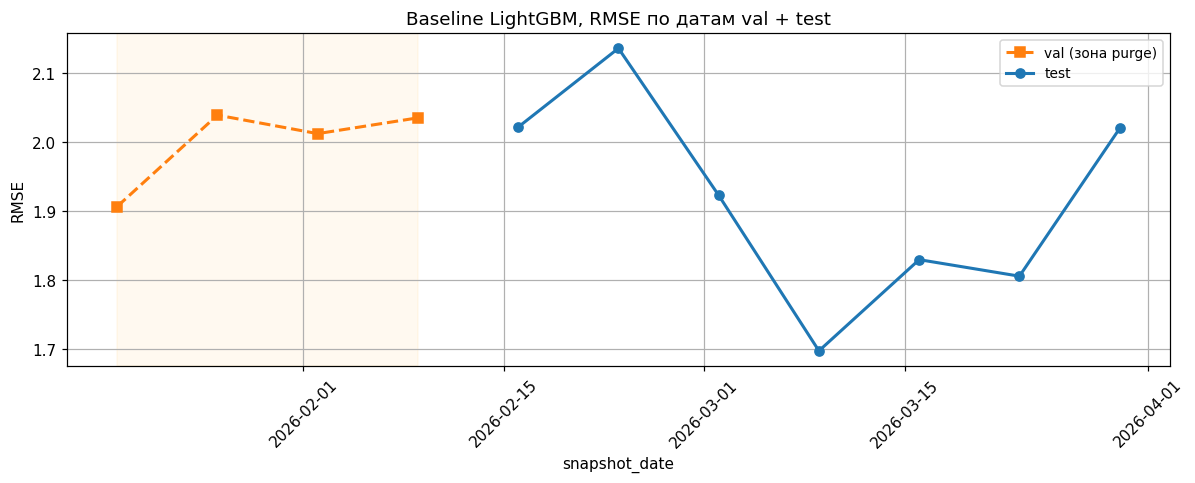

In [15]:
t0 = time.time()
base_lgbm = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"],
    model_kind="lgbm", train_end=train_end, mode="static",
    val_dates=val_dates, test_dates=test_dates,
    log_target=True, lgb_params=lgb_base, verbose=True,
)
print(f"\n[LGBM] занял {time.time()-t0:.1f}s")
base_lgbm.to_csv(os.path.join(ART_DIR, "baseline_lgbm.csv"), index=False)
print("метрик по val:", stability_row("LGBM val", base_lgbm, "val"))
print("метрик по test:", stability_row("LGBM test", base_lgbm, "test"))

plot_val_test_curve(base_lgbm, "Spearman",
                    "Baseline LightGBM, Spearman по датам val + test")
save_fig("baseline_lgbm_spearman.png")
plot_val_test_curve(base_lgbm, "RMSE",
                    "Baseline LightGBM, RMSE по датам val + test")
save_fig("baseline_lgbm_rmse.png")

## 9. Baseline — MLP (sklearn)

Маленькая нейросеть `(64, 32)` с ReLU + Adam, log-таргет, early stopping.
Препроцессинг — тот же что у Ridge (one-hot + frequency + StandardScaler).
Обучаем один раз на train (благодаря кэшу в `temporal_eval`), потом просто
предсказываем для каждой val/test даты.

**Скорость.** На 880 тыс. строк один fit занимает ~30-90 секунд. Static-кэш
делает baseline MLP практически таким же быстрым, как Ridge.

BASELINE — MLP (sklearn, static, EXTENDED)
mlp | val | 2026-01-19 | n_train=886750 | n_test=130640
mlp | val | 2026-01-26 | n_train=886750 | n_test=121595
mlp | val | 2026-02-02 | n_train=886750 | n_test=107334
mlp | val | 2026-02-09 | n_train=886750 | n_test=99515
mlp | test | 2026-02-16 | n_train=886750 | n_test=91597
mlp | test | 2026-02-23 | n_train=886750 | n_test=84538
mlp | test | 2026-03-02 | n_train=886750 | n_test=83393
mlp | test | 2026-03-09 | n_train=886750 | n_test=80805
mlp | test | 2026-03-16 | n_train=886750 | n_test=78467
mlp | test | 2026-03-23 | n_train=886750 | n_test=72514
mlp | test | 2026-03-30 | n_train=886750 | n_test=65633

[MLP] заняло 37.3s

MLP сводка по val: {'model': 'MLP val', 'Spearman_mean': np.float64(0.3705554754474297), 'Spearman_std': np.float64(0.005868654157105022), 'stability': np.float64(0.9941655860008654), 'slope': np.float64(0.002417035615557057), 'R2_mean': np.float64(0.251910046673433), 'RMSE_mean': np.float64(2.068439129366561), 'MAE_mea

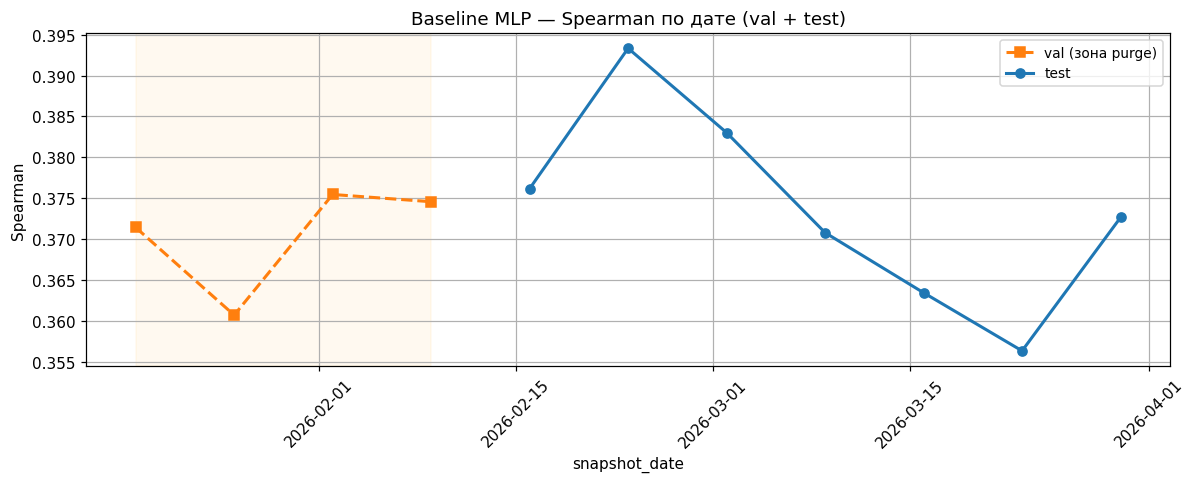

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/baseline_mlp_rmse.png


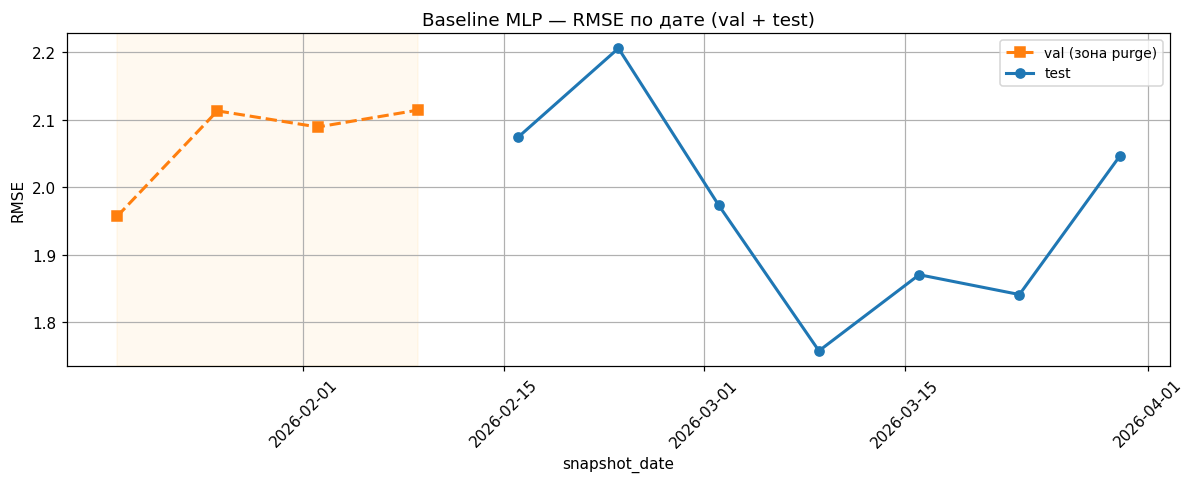

In [16]:
print("BASELINE — MLP (sklearn, static, EXTENDED)")
t0 = time.time()
base_mlp = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"],
    model_kind="mlp", train_end=train_end, mode="static",
    val_dates=val_dates, test_dates=test_dates,
    mlp_hidden=(64, 32), mlp_epochs=20, verbose=True,
)
print(f"\n[MLP] заняло {time.time()-t0:.1f}s")
base_mlp.to_csv(os.path.join(ART_DIR, "baseline_mlp.csv"), index=False)
print("\nMLP сводка по val:", stability_row("MLP val", base_mlp, "val"))
print("MLP сводка по test:", stability_row("MLP test", base_mlp, "test"))
plot_val_test_curve(base_mlp, "Spearman", "Baseline MLP — Spearman по дате (val + test)")
save_fig("baseline_mlp_spearman.png")
plot_val_test_curve(base_mlp, "RMSE", "Baseline MLP — RMSE по дате (val + test)")
save_fig("baseline_mlp_rmse.png")

## 10. Сравнение трёх baseline на одних графиках

Кладём кривые Ridge / LightGBM / MLP на одни оси по Spearman и RMSE.
Видно сразу:
- какая модель лучше «из коробки» по среднему качеству;
- у какой круче падение от val к test (большая деградация);
- какая ровнее во времени.

В сводной таблице — `Spearman_mean`, `Spearman_std`, `stability` для val и
test отдельно.

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/baselines_overlay_spearman.png


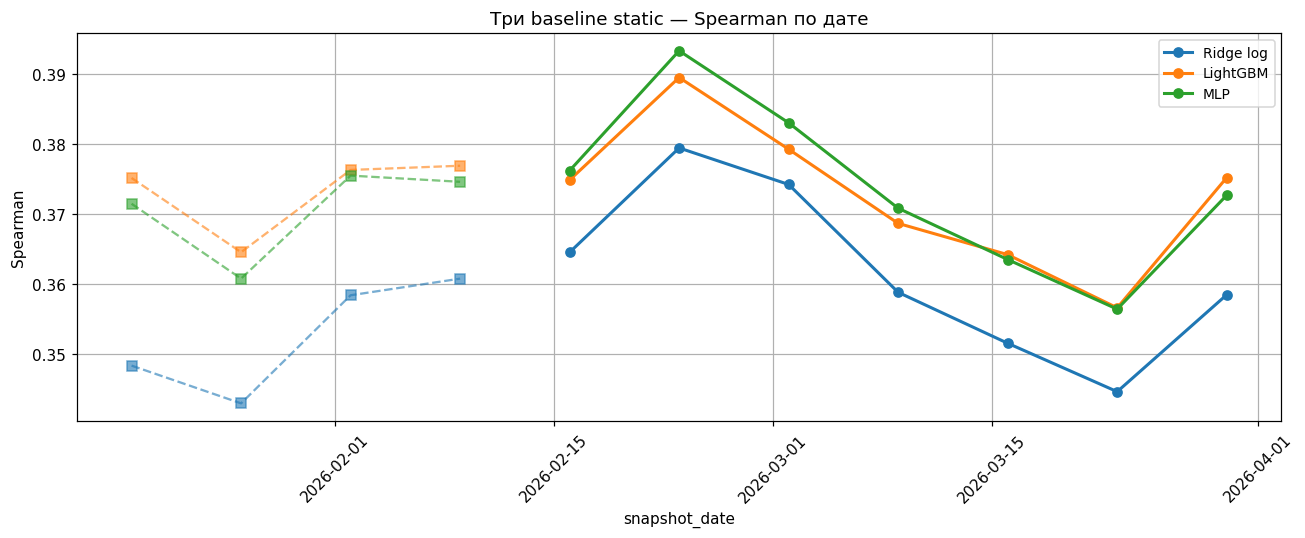

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/baselines_overlay_rmse.png


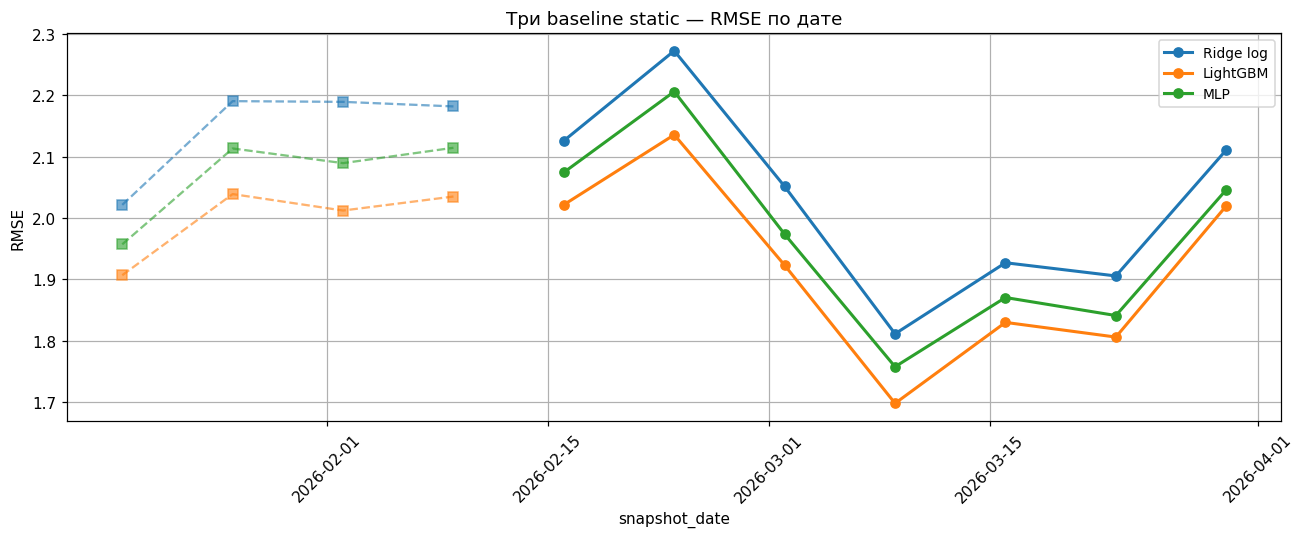


Сводка baselines (val + test):
           model  Spearman_mean  Spearman_std  stability   slope  R2_mean  RMSE_mean  MAE_mean
 Ridge log (val)         0.3526        0.0073     0.9928  0.0053   0.1952     2.1457    0.2692
Ridge log (test)         0.3616        0.0113     0.9888 -0.0040   0.2001     2.0291    0.2659
  LightGBM (val)         0.3732        0.0051     0.9950  0.0017   0.3017     1.9981    0.2517
 LightGBM (test)         0.3726        0.0099     0.9902 -0.0029   0.2846     1.9189    0.2488
       MLP (val)         0.3706        0.0059     0.9942  0.0024   0.2519     2.0684    0.2487
      MLP (test)         0.3737        0.0113     0.9888 -0.0037   0.2485     1.9668    0.2467


In [17]:
baselines = {"Ridge log": base_ridge, "LightGBM": base_lgbm, "MLP": base_mlp}

plot_three_curves(baselines, "Spearman", "Три baseline static — Spearman по дате")
save_fig("baselines_overlay_spearman.png")

plot_three_curves(baselines, "RMSE", "Три baseline static — RMSE по дате")
save_fig("baselines_overlay_rmse.png")

rows = []
for name, c in baselines.items():
    rows.append(stability_row(f"{name} (val)", c, "val"))
    rows.append(stability_row(f"{name} (test)", c, "test"))
baselines_summary = pd.DataFrame([r for r in rows if r is not None])
print("\nСводка baselines (val + test):")
print(baselines_summary.round(4).to_string(index=False))
baselines_summary.to_csv(os.path.join(ART_DIR, "baselines_summary.csv"), index=False)

## 11. PSI — Population Stability Index

Стандартная метрика дрейфа: разница распределений признака между train и
тест-снэпшотом. Эмпирические пороги: <0.10 — стабильно, 0.10–0.25 —
умеренный сдвиг, >0.25 — сильный сдвиг.

Считаем PSI отдельно для числовых (`psi_num`) и для двух высококардинальных
категорий (`psi_cat`). `was_nan`-флаги в PSI не идут — для бинарных
индикаторов индекс неинформативен.

ДИАГНОСТИКА ДРЕЙФА — PSI
Топ-15 признаков по среднему PSI:
app_version_name                                  6.694
country_iso_code                                  0.182
days_since_first_seen                             0.066
ml_snap_kills_last_minute_mean_30d                0.054
ml_init_days_since_install_last_30d               0.040
ml_init_session_cnt_last_30d                      0.039
ml_snap_itemtoken_balance_mean_30d                0.035
ml_init_global_death_count_last_30d               0.033
ml_snap_itemtoken_revenue_last_minute_sum_30d     0.032
ml_snap_health_mean_30d                           0.030
ml_snap_health_ratio_min_30d                      0.030
ml_snap_damage_mean_30d                           0.029
ml_snap_itemtoken_ad_reward_calculate_mean_30d    0.029
ml_snap_player_dps_mean_30d                       0.029
ml_snap_money_balance_mean_30d                    0.029
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/psi_top5.png


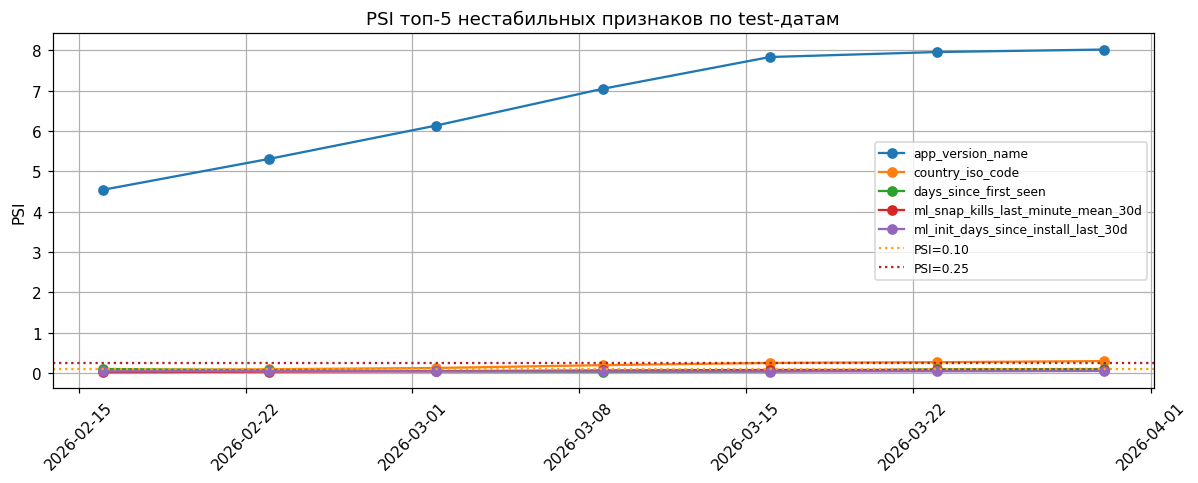

In [18]:
print("ДИАГНОСТИКА ДРЕЙФА — PSI")

def psi_num(ref, cur, bins=10):
    qs = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
    if len(qs) < 3:
        return 0.0
    r = np.histogram(ref, qs)[0] / max(len(ref), 1)
    c = np.histogram(cur, qs)[0] / max(len(cur), 1)
    r = np.clip(r, 1e-4, None)
    c = np.clip(c, 1e-4, None)
    return float(np.sum((c - r) * np.log(c / r)))


def psi_cat(ref, cur):
    r = ref.value_counts(normalize=True)
    c = cur.value_counts(normalize=True)
    cats = set(r.index) | set(c.index)
    rr = np.clip(np.array([r.get(k, 0) for k in cats]), 1e-4, None)
    cc = np.clip(np.array([c.get(k, 0) for k in cats]), 1e-4, None)
    return float(np.sum((cc - rr) * np.log(cc / rr)))


ref_df = df[df["snapshot_date"] <= train_end]
PSI_NUM_FEATS = BASELINE_NUM + ML_EXT_NUM
psi_num_tab = pd.DataFrame(
    {f: [psi_num(ref_df[f].values, df[df["snapshot_date"] == d][f].values) for d in test_dates]
     for f in PSI_NUM_FEATS},
    index=[d.date() for d in test_dates],
)
psi_cat_tab = pd.DataFrame(
    {f: [psi_cat(ref_df[f], df[df["snapshot_date"] == d][f]) for d in test_dates]
     for f in CAT_HIGH},
    index=[d.date() for d in test_dates],
)
mean_psi = pd.concat([psi_num_tab.mean(), psi_cat_tab.mean()]).sort_values(ascending=False)
print("Топ-15 признаков по среднему PSI:")
print(mean_psi.head(15).round(3).to_string())
mean_psi.to_csv(os.path.join(ART_DIR, "psi_mean.csv"))

fig, ax = plt.subplots(figsize=(11, 4.5))
for f in mean_psi.head(5).index:
    src = psi_cat_tab if f in CAT_HIGH else psi_num_tab
    ax.plot(src.index, src[f], marker="o", label=f)
ax.axhline(0.10, ls=":", c="orange", label="PSI=0.10")
ax.axhline(0.25, ls=":", c="firebrick", label="PSI=0.25")
ax.set_title("PSI топ-5 нестабильных признаков по test-датам")
ax.set_ylabel("PSI")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)
save_fig("psi_top5.png")

## 12. Adversarial validation + важность признаков

Тренируем бинарный LightGBM-классификатор `is_test` (1 = строка из test,
0 = из train) **только на признаках без таргета**. ROC-AUC ≈ 0.5 — train и
test неотличимы, дрейфа нет; AUC > 0.9 — сильный дрейф.

**Важно:** топ-10 признаков по `feature_importance` — **это не AUC**, а
абсолютные значения выигрыша по loss (gain), которые могут быть в миллионах
на больших датасетах. Они показывают, **какая колонка** доминирует в
способности классификатора различать train и test.

На графике топ-15 показаны в долях от общей суммы gain — сразу видно,
концентрирован ли дрейф в одной колонке или размазан.

Объединение `mean_psi > 0.10` и `top adversarial` даёт список `UNSTABLE` —
кандидаты на удаление в эксперименте `drop_unstable`.

ADVERSARIAL VALIDATION (train vs test)
Adversarial AUC: 0.9733  (это бинарная AUC, в [0,1])
Топ-10 признаков (gain — НЕ AUC, абсолютные значения выигрыша по loss):
app_version_name                          2198940.0
days_since_first_seen                      199902.0
country_iso_code                            55973.0
ml_init_days_since_install_last_30d         39652.0
playtime_hours_14d                          35991.0
events_count_7d                             20814.0
ml_init_avg_playtime_lifetime_last_30d       8641.0
ml_init_hours_since_last_game_last_30d       8023.0
events_count_30d                             7427.0
ml_snap_kills_last_minute_mean_30d           6129.0
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/adversarial_top_importance.png


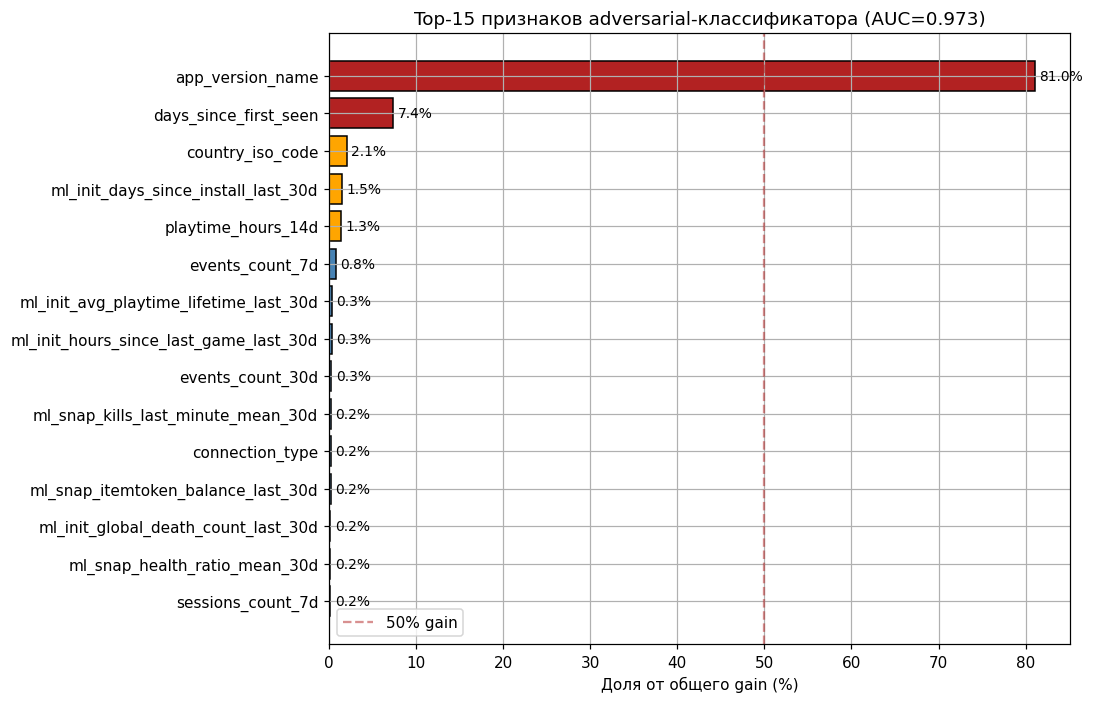


Удалить (PSI > 0.10 ∪ top adversarial): 8
  app_version_name
  country_iso_code
  days_since_first_seen
  events_count_7d
  ml_init_avg_playtime_lifetime_last_30d
  ml_init_days_since_install_last_30d
  ml_init_hours_since_last_game_last_30d
  playtime_hours_14d


In [19]:
print("ADVERSARIAL VALIDATION (train vs test)")
SAMPLE_PER_SIDE = 200_000
tr_sample = ref_df.sample(n=min(SAMPLE_PER_SIDE, len(ref_df)), random_state=random_state)
te_df_all = df[df["snapshot_date"].isin([np.datetime64(d) for d in test_dates])]
te_sample = te_df_all.sample(n=min(SAMPLE_PER_SIDE, len(te_df_all)), random_state=random_state)

adv_feats = BASELINE_NUM + ML_EXT_NUM + WASNAN + CAT_LOW + CAT_HIGH
adv_X = pd.concat([tr_sample[adv_feats], te_sample[adv_feats]], axis=0).reset_index(drop=True)
for c in CAT_LOW + CAT_HIGH:
    adv_X[c] = adv_X[c].astype("category")
adv_y = np.concatenate([np.zeros(len(tr_sample)), np.ones(len(te_sample))])
rng = np.random.default_rng(random_state)
order = rng.permutation(len(adv_X))
adv_X = adv_X.iloc[order].reset_index(drop=True)
adv_y = adv_y[order]
sp = int(0.7 * len(adv_X))

adv_clf = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=63,
    feature_fraction=0.9, bagging_fraction=0.9, bagging_freq=1,
    random_state=random_state, n_jobs=-1, verbose=-1,
)
adv_clf.fit(adv_X.iloc[:sp], adv_y[:sp],
            eval_set=[(adv_X.iloc[sp:], adv_y[sp:])],
            categorical_feature=CAT_LOW + CAT_HIGH,
            callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
adv_auc = roc_auc_score(adv_y[sp:], adv_clf.predict_proba(adv_X.iloc[sp:])[:, 1])
print(f"Adversarial AUC: {adv_auc:.4f}  (это бинарная AUC, в [0,1])")
adv_imp = pd.Series(adv_clf.booster_.feature_importance(importance_type="gain"),
                    index=adv_clf.feature_name_).sort_values(ascending=False)
top_adv = adv_imp.head(10)
print("Топ-10 признаков (gain — НЕ AUC, абсолютные значения выигрыша по loss):")
print(top_adv.round(0).to_string())
adv_imp.to_csv(os.path.join(ART_DIR, "adversarial_importance.csv"))
top15 = adv_imp.head(15)
share = (top15 / adv_imp.sum()) * 100
fig, ax = plt.subplots(figsize=(10, 6.5))
colors = ["firebrick" if v > 5 else ("orange" if v > 1 else "steelblue") for v in share]
ax.barh(top15.index[::-1], share.values[::-1], color=colors[::-1], edgecolor="black")
for i, v in enumerate(share.values[::-1]):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)
ax.axvline(50, color="firebrick", ls="--", alpha=0.5, label="50% gain")
ax.set_xlabel("Доля от общего gain (%)")
ax.set_title(f"Top-15 признаков adversarial-классификатора (AUC={adv_auc:.3f})")
ax.legend()
save_fig("adversarial_top_importance.png")
UNSTABLE = sorted(set(mean_psi[mean_psi > 0.10].index[:20]) | set(top_adv.index[:8]))
print(f"\nУдалить (PSI > 0.10 ∪ top adversarial): {len(UNSTABLE)}")
for u in UNSTABLE:
    print(f"  {u}")

def stable_subset(cfg_in):
    return dict(
        num=[c for c in cfg_in["num"] if c not in UNSTABLE],
        low=[c for c in cfg_in["low"] if c not in UNSTABLE],
        high=[c for c in cfg_in["high"] if c not in UNSTABLE],
    )
stable_cfg = stable_subset(cfg)

## 13. Линейная модель — extended

Пять вариантов, каждый — один шаг в сторону стабилизации:

1. **Linear raw** — без log-преобразований и без log-таргета;
2. **Linear log** — signed log1p числовых + log1p(target);
3. **Ridge log** — добавляем L2 (это наш baseline из Части 7);
4. **Ridge log + drop_unstable** — выкидываем признаки из `UNSTABLE`;
5. **Ridge log + sliding (42d)** — rolling retrain.

Все сравниваются на одних графиках. Сводная таблица показывает Spearman,
stability и slope (наклон деградации).

ЛИНЕЙНАЯ МОДЕЛЬ — extended

 Linear raw 

 Linear log 
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/linear_compare_spearman.png


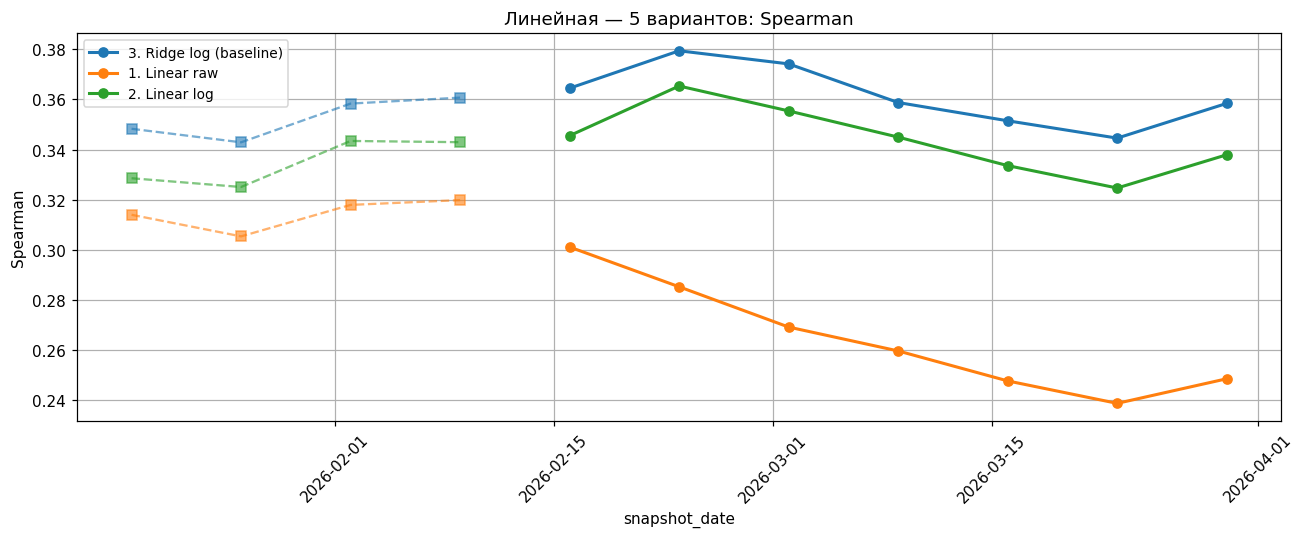

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/linear_compare_rmse.png


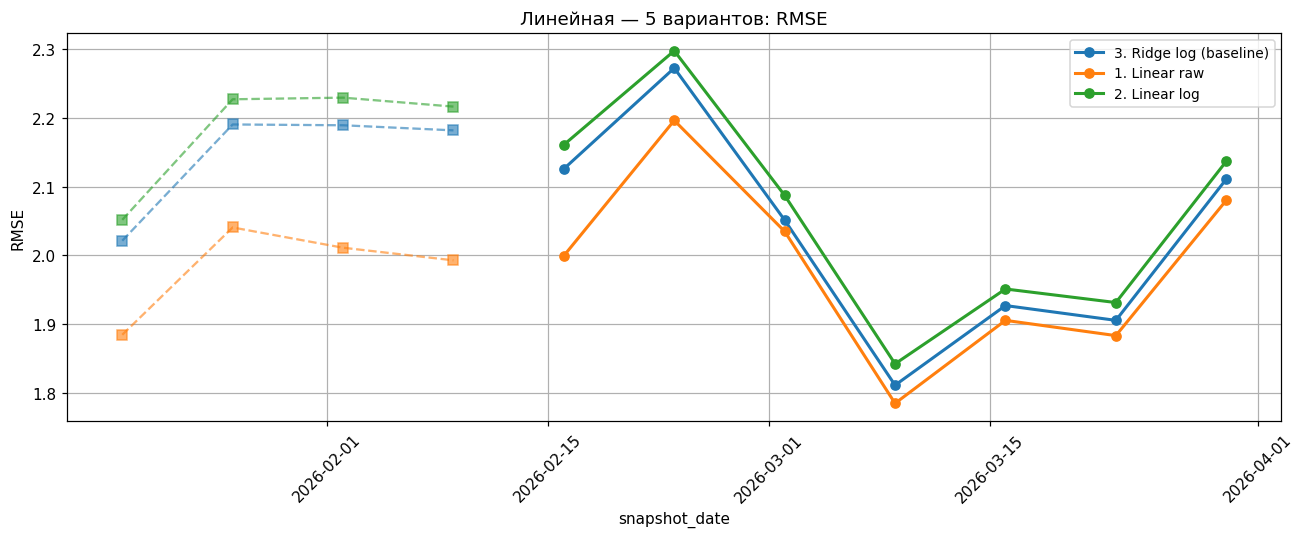


Линейная — сводка по TEST:
                  model  Spearman_mean  Spearman_std  stability   slope  R2_mean  RMSE_mean  MAE_mean
3. Ridge log (baseline)         0.3616        0.0113     0.9888 -0.0040   0.2001     2.0291    0.2659
          1. Linear raw         0.2642        0.0208     0.9796 -0.0097   0.2346     1.9834    0.3738
          2. Linear log         0.3439        0.0126     0.9876 -0.0045   0.1770     2.0581    0.2757


In [20]:
print("ЛИНЕЙНАЯ МОДЕЛЬ — extended")
linear_curves = {"3. Ridge log (baseline)": base_ridge}

print("\n Linear raw ")
linear_curves["1. Linear raw"] = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"], "linear", train_end, "static",
    val_dates=val_dates, test_dates=test_dates,
    log_target=False, use_log_num=False,
)

print("\n Linear log ")
linear_curves["2. Linear log"] = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"], "linear", train_end, "static",
    val_dates=val_dates, test_dates=test_dates,
    log_target=True, use_log_num=True,
)

plot_three_curves(linear_curves, "Spearman", "Линейная — 5 вариантов: Spearman")
save_fig("linear_compare_spearman.png")
plot_three_curves(linear_curves, "RMSE", "Линейная — 5 вариантов: RMSE")
save_fig("linear_compare_rmse.png")

linear_summary = pd.DataFrame([stability_row(n, c, "test") for n, c in linear_curves.items() if c is not None])
print("\nЛинейная — сводка по TEST:")
print(linear_summary.round(4).to_string(index=False))
linear_summary.to_csv(os.path.join(ART_DIR, "linear_summary.csv"), index=False)

## 14. LightGBM — extended, исследование по улучшению стабильности 


  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_lgbm_no_log.png


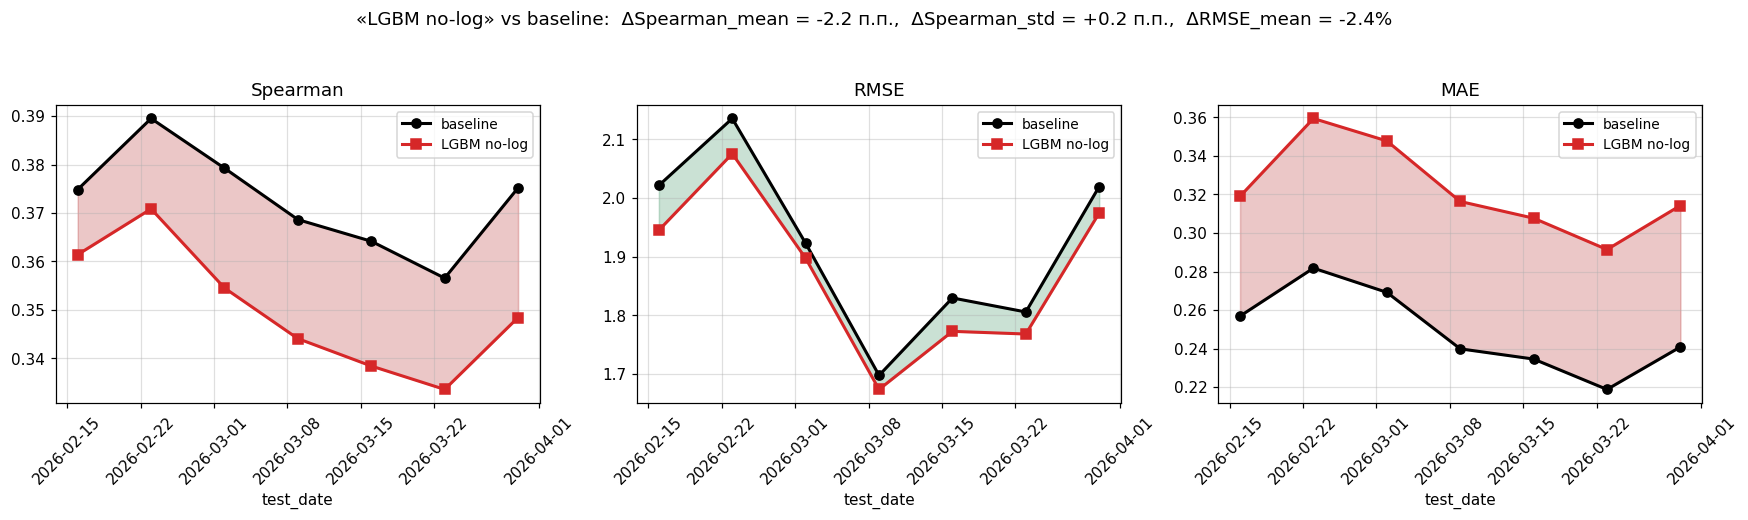

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_lgbm_regularized.png


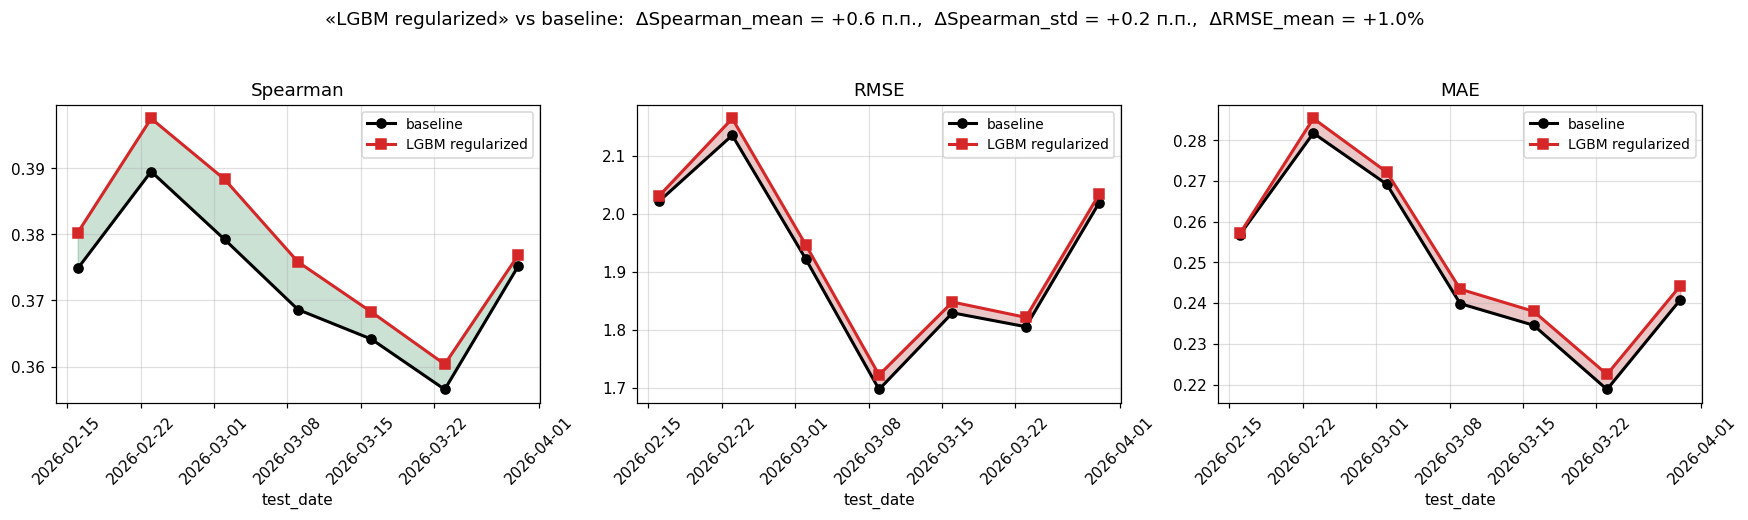

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_lgbm_drop_unstable.png


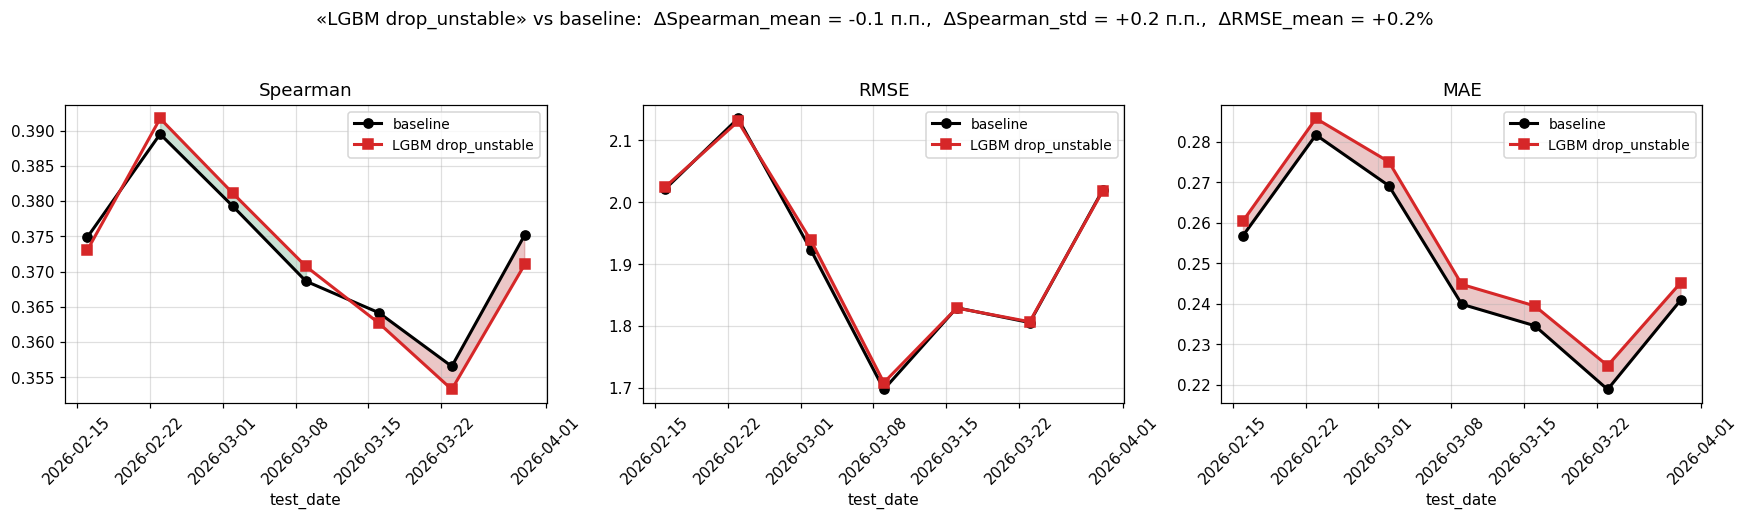

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_lgbm_huber.png


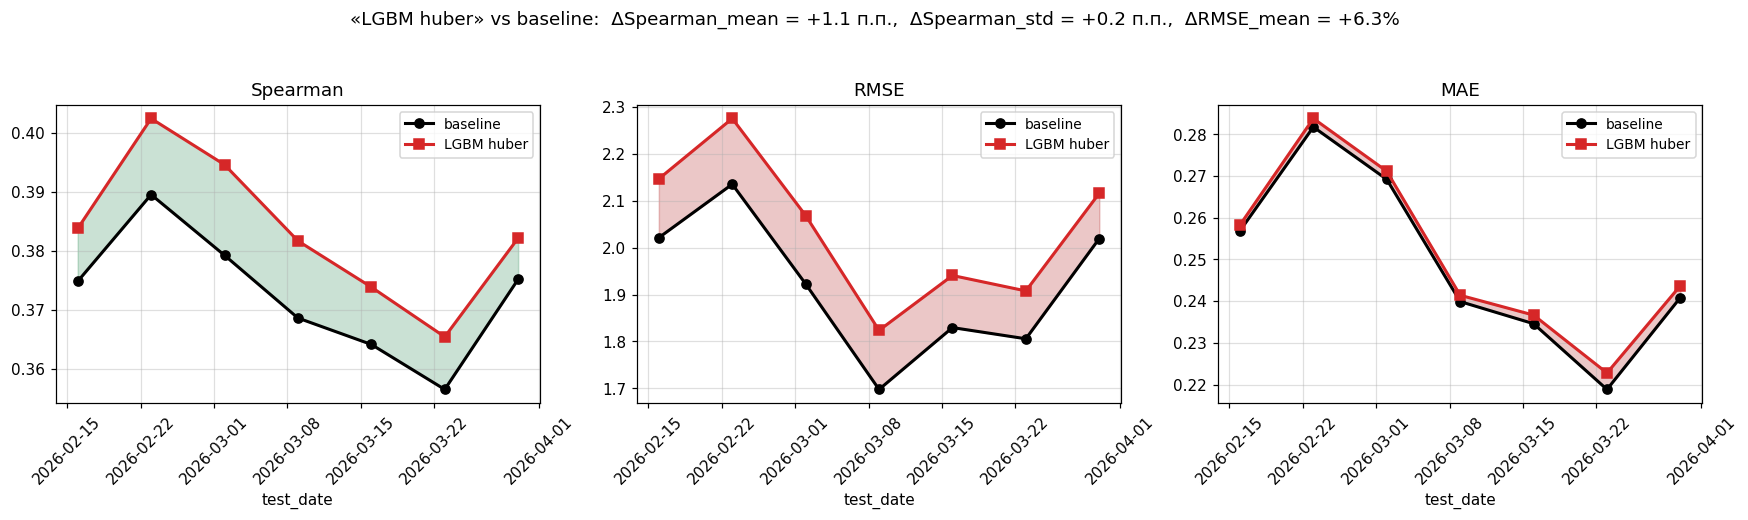

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_lgbm_quantile.png


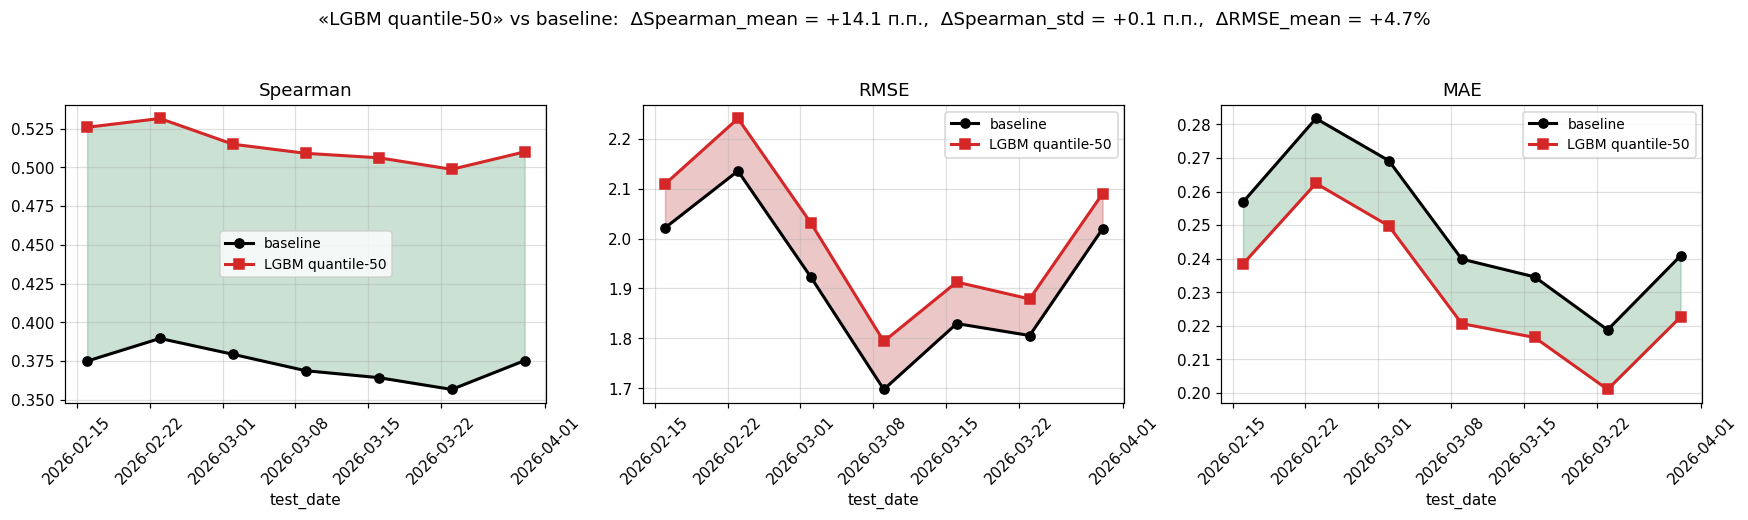

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_lgbm_two_stage.png


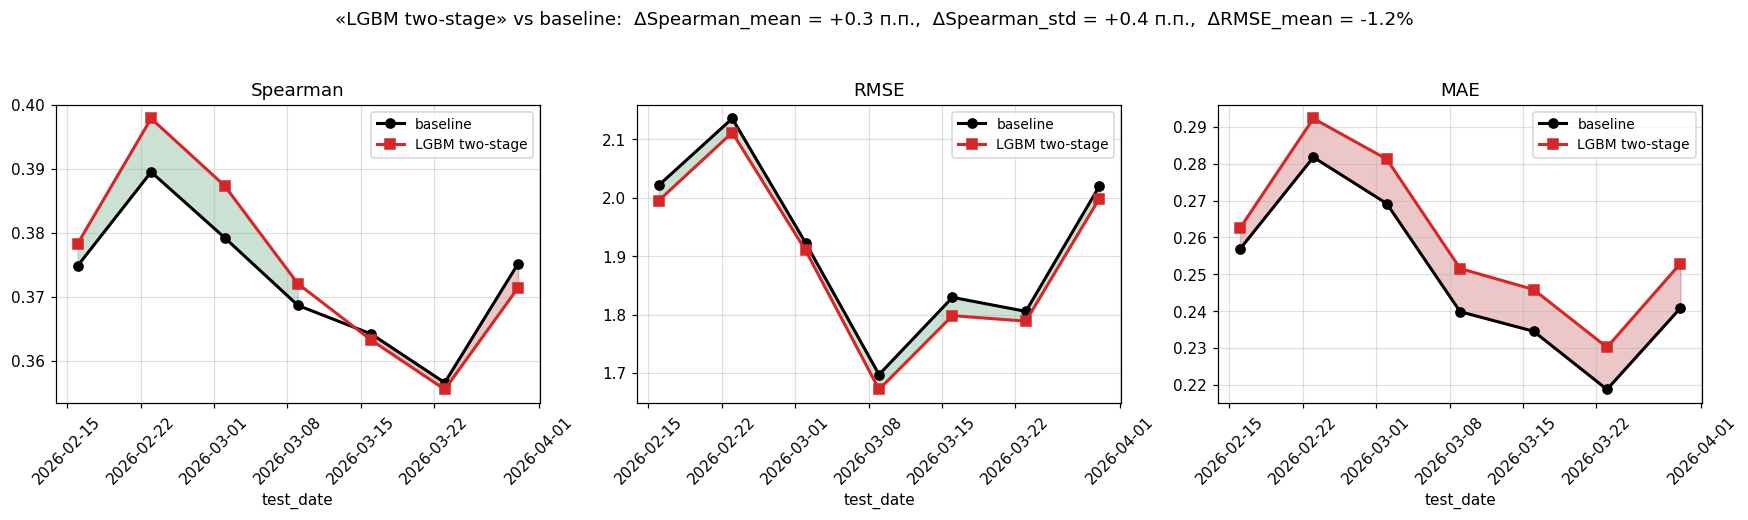

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_lgbm_sliding_42.png


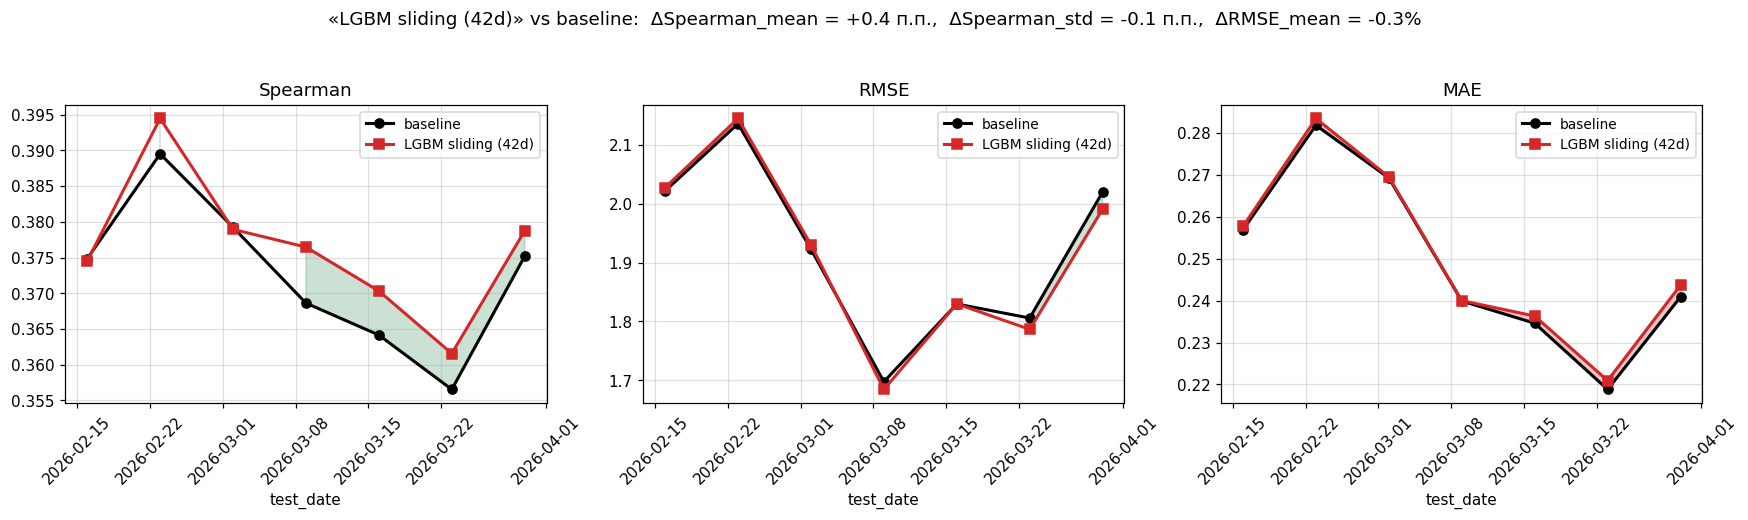

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/lgbm_all_experiments_spearman.png


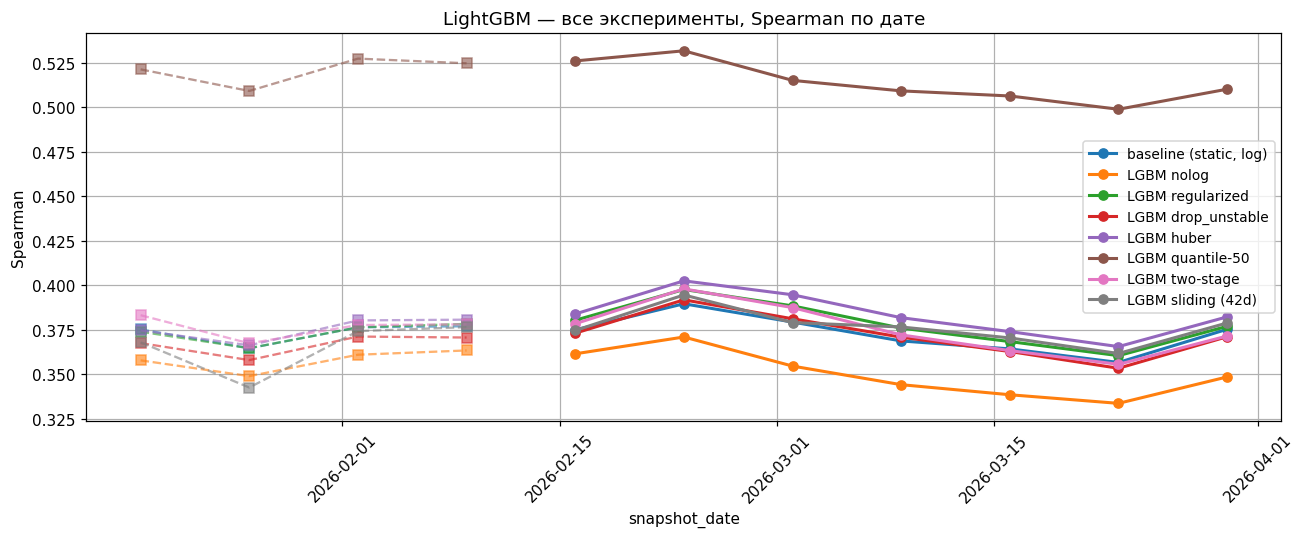

Результаты:
                 model  Spearman_mean  Spearman_std  stability   slope  R2_mean  RMSE_mean  MAE_mean
baseline (static, log)         0.3726        0.0099     0.9902 -0.0029   0.2846     1.9189    0.2488
            LGBM nolog         0.3502        0.0121     0.9880 -0.0046   0.3185     1.8724    0.3222
      LGBM regularized         0.3782        0.0114     0.9888 -0.0037   0.2699     1.9385    0.2518
    LGBM drop_unstable         0.3719        0.0114     0.9887 -0.0036   0.2819     1.9224    0.2537
            LGBM huber         0.3834        0.0114     0.9888 -0.0036   0.1915     2.0400    0.2511
      LGBM quantile-50         0.5139        0.0106     0.9895 -0.0044   0.2165     2.0082    0.2302
        LGBM two-stage         0.3751        0.0133     0.9869 -0.0046   0.3013     1.8964    0.2595
    LGBM sliding (42d)         0.3764        0.0092     0.9908 -0.0022   0.2891     1.9133    0.2502


In [21]:
def fit_two_stage_lgbm(df, train_mask, val_dates, test_dates,
                       num_cols, low_card_cols, high_card_cols):
    train_df = df[train_mask]
    y_train = train_df[TARGET].values
    feature_cols = num_cols + low_card_cols + high_card_cols

    X_train = train_df[feature_cols].copy()
    for col in low_card_cols + high_card_cols:
        X_train[col] = X_train[col].astype("category")

    classifier_params = dict(lgb_base)
    classifier_params.update(
        objective="binary",
        metric="auc",
    )
    classifier = lgb.LGBMClassifier(**classifier_params)
    is_active = (y_train > 0).astype(int)
    classifier.fit(
        X_train,
        is_active,
        categorical_feature=low_card_cols + high_card_cols,
    )

    active_mask = y_train > 0
    regressor = lgb.LGBMRegressor(**lgb_base)
    regressor.fit(
        X_train[active_mask],
        np.log1p(np.clip(y_train[active_mask], 0, None)),
        categorical_feature=low_card_cols + high_card_cols,
    )

    rows = []
    dates_with_split = (
        [(date, "val") for date in val_dates]
        + [(date, "test") for date in test_dates]
    )
    for current_date, split_name in dates_with_split:
        test_df = df[df["snapshot_date"] == current_date]
        if len(test_df) < 200:
            continue
        y_test = test_df[TARGET].values
        X_test = test_df[feature_cols].copy()
        for col in low_card_cols + high_card_cols:
            X_test[col] = X_test[col].astype("category")

        prob_active = classifier.predict_proba(X_test)[:, 1]
        expected_hours_if_active = regressor.predict(X_test)
        expected_hours_if_active = np.expm1(np.clip(expected_hours_if_active, None, LOG_cap))

        pred = prob_active * expected_hours_if_active
        pred = np.clip(pred, 0, CAP)
        pred = np.nan_to_num(pred, nan=0.0, posinf=CAP, neginf=0.0)

        row = {
            "test_date": pd.Timestamp(current_date),
            "split": split_name,
        }
        row.update(metrics(y_test, pred))
        rows.append(row)
    return pd.DataFrame(rows)

lgbm_curves = {"baseline (static, log)": base_lgbm}

lgbm_curves["LGBM nolog"] = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"], "lgbm", train_end, "static",
    val_dates=val_dates,
    test_dates=test_dates,
    log_target=False,
    lgb_params=lgb_base,
)
plot_exp_vs_baseline(
    "LGBM no-log",
    lgbm_curves["LGBM nolog"],
    base_lgbm,
    save_name="exp_lgbm_no_log.png",
)


regularized_params = dict(lgb_base)
regularized_params.update(
    num_leaves=31,
    min_data_in_leaf=500,
    reg_alpha=1.0,
    reg_lambda=5.0,
    feature_fraction=0.7,
    bagging_fraction=0.7,
    n_estimators=600,
    learning_rate=0.03,
)
lgbm_curves["LGBM regularized"] = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"], "lgbm", train_end, "static",
    val_dates=val_dates,
    test_dates=test_dates,
    log_target=True,
    lgb_params=regularized_params,
)
plot_exp_vs_baseline(
    "LGBM regularized",
    lgbm_curves["LGBM regularized"],
    base_lgbm,
    save_name="exp_lgbm_regularized.png",
)


lgbm_curves["LGBM drop_unstable"] = temporal_eval(
    df, stable_cfg["num"], stable_cfg["low"], stable_cfg["high"], "lgbm", train_end, "static",
    val_dates=val_dates,
    test_dates=test_dates,
    log_target=True,
    lgb_params=lgb_base,
)
plot_exp_vs_baseline(
    "LGBM drop_unstable",
    lgbm_curves["LGBM drop_unstable"],
    base_lgbm,
    save_name="exp_lgbm_drop_unstable.png",
)

huber_params = dict(lgb_base)
huber_params.update(
    objective="huber",
    alpha=0.9,
)
lgbm_curves["LGBM huber"] = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"], "lgbm", train_end, "static",
    val_dates=val_dates,
    test_dates=test_dates,
    log_target=False,
    lgb_params=huber_params,
)
plot_exp_vs_baseline(
    "LGBM huber",
    lgbm_curves["LGBM huber"],
    base_lgbm,
    save_name="exp_lgbm_huber.png",
)
quantile_params = dict(lgb_base)
quantile_params.update(
    objective="quantile",
    alpha=0.5,
)
lgbm_curves["LGBM quantile-50"] = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"], "lgbm", train_end, "static",
    val_dates=val_dates,
    test_dates=test_dates,
    log_target=False,
    lgb_params=quantile_params,
)
plot_exp_vs_baseline(
    "LGBM quantile-50",
    lgbm_curves["LGBM quantile-50"],
    base_lgbm,
    save_name="exp_lgbm_quantile.png",
)

lgbm_curves["LGBM two-stage"] = fit_two_stage_lgbm(
    df,
    df["snapshot_date"] <= train_end,
    val_dates,
    test_dates,
    cfg["num"],
    cfg["low"],
    cfg["high"],
)
plot_exp_vs_baseline(
    "LGBM two-stage",
    lgbm_curves["LGBM two-stage"],
    base_lgbm,
    save_name="exp_lgbm_two_stage.png",
)

lgbm_curves["LGBM sliding (42d)"] = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"], "lgbm", train_end, "sliding",
    train_win_days=42,
    val_dates=val_dates,
    test_dates=test_dates,
    log_target=True,
    lgb_params=lgb_base,
)
plot_exp_vs_baseline(
    "LGBM sliding (42d)",
    lgbm_curves["LGBM sliding (42d)"],
    base_lgbm,
    save_name="exp_lgbm_sliding_42.png",
)
lgbm_summary = pd.DataFrame(
    [stability_row(name, curve, "test") for name, curve in lgbm_curves.items() if curve is not None]
)

plot_three_curves(lgbm_curves, "Spearman", "LightGBM — все эксперименты, Spearman по дате")
save_fig("lgbm_all_experiments_spearman.png")
print("Результаты:")
print(lgbm_summary.round(4).to_string(index=False))
lgbm_summary.to_csv(os.path.join(ART_DIR, "lgbm_summary.csv"), index=False)

## 14b. MLP extended — 5 экспериментов

В этой части добавляем мини-исследование MLP — 5 экспериментов, выполнимых на `sklearn.MLPRegressor`.


Каждый эксперимент сравнивается с baseline MLP по 3 метрикам (Spearman, RMSE, MAE)
на per-experiment графике с заливкой улучшение/ухудшение. Дальше — сводная
таблица + Парето.


In [22]:
from sklearn.neural_network import MLPRegressor, MLPClassifier


def make_mlp_regressor(hidden_layers=(64, 32), max_iter=25, alpha=1e-3):
    return MLPRegressor(
        hidden_layer_sizes=hidden_layers,
        activation="relu",
        solver="adam",
        alpha=alpha,
        batch_size=512,
        learning_rate_init=1e-3,
        max_iter=max_iter,
        early_stopping=True,
        n_iter_no_change=5,
        validation_fraction=0.1,
        random_state=random_state,
        verbose=False,
    )

def make_mlp_classifier(hidden_layers=(64, 32), max_iter=20, alpha=1e-3):
    return MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation="relu",
        solver="adam",
        alpha=alpha,
        batch_size=512,
        learning_rate_init=1e-3,
        max_iter=max_iter,
        early_stopping=True,
        n_iter_no_change=4,
        validation_fraction=0.1,
        random_state=random_state,
        verbose=False,
    )

def prepare_target(y, use_log_target=True):
    y = y.astype(np.float32)
    if use_log_target:
        return np.log1p(np.clip(y, 0, None))

    return y


def restore_prediction(pred, use_log_target=True):
    if use_log_target:
        pred = np.expm1(np.clip(pred, None, LOG_cap))
    pred = np.clip(pred, 0, CAP)
    pred = np.nan_to_num(pred, nan=0.0, posinf=CAP, neginf=0.0)
    return pred


def evaluate_model_by_dates(model, train_df, df, dates_with_split,
                            num_cols, low_card_cols, high_card_cols,
                            use_log_target=True):
    rows = []
    for current_date, split_name in dates_with_split:
        test_df = df[df["snapshot_date"] == current_date]
        y_true = test_df["target_hours_next_30d"].astype(np.float32).values
        _, X_test = prep_X_for_linear(
            train_df,
            test_df,
            num_cols,
            low_card_cols,
            high_card_cols,
            use_log=True,
        )
        pred = model.predict(X_test)
        pred = restore_prediction(pred, use_log_target)
        row = {
            "test_date": pd.Timestamp(current_date),
            "split": split_name,
        }
        row.update(metrics(y_true, pred))
        rows.append(row)
    return pd.DataFrame(rows)


def fit_static_mlp(df, train_mask, val_dates, test_dates,
                   num_cols, low_card_cols, high_card_cols,
                   use_log_target=True,
                   hidden_layers=(64, 32),
                   max_iter=25,
                   alpha=1e-3):
    train_df = df[train_mask]
    y_train = train_df["target_hours_next_30d"].astype(np.float32).values
    y_train_fit = prepare_target(y_train, use_log_target)
    first_eval_date = val_dates[0] if len(val_dates) > 0 else test_dates[0]
    first_eval_df = df[df["snapshot_date"] == first_eval_date]
    X_train, _ = prep_X_for_linear(
        train_df,
        first_eval_df,
        num_cols,
        low_card_cols,
        high_card_cols,
        use_log=True,
    )
    model = make_mlp_regressor(
        hidden_layers=hidden_layers,
        max_iter=max_iter,
        alpha=alpha,
    )
    model.fit(X_train, y_train_fit)
    dates_with_split = (
        [(date, "val") for date in val_dates]
        + [(date, "test") for date in test_dates]
    )
    return evaluate_model_by_dates(
        model=model,
        train_df=train_df,
        df=df,
        dates_with_split=dates_with_split,
        num_cols=num_cols,
        low_card_cols=low_card_cols,
        high_card_cols=high_card_cols,
        use_log_target=use_log_target,
    )


def fit_sliding_mlp(df, val_dates, test_dates,
                    num_cols, low_card_cols, high_card_cols,
                    train_window_days=70,
                    use_log_target=True,
                    hidden_layers=(64, 32),
                    max_iter=20,
                    alpha=1e-3):
    rows = []
    purge_period = pd.Timedelta(days=H)
    dates_with_split = (
        [(date, "val") for date in val_dates]
        + [(date, "test") for date in test_dates]
    )
    for current_date, split_name in dates_with_split:
        current_date = pd.Timestamp(current_date)
        train_start = current_date - purge_period - pd.Timedelta(days=train_window_days)
        train_end_local = current_date - purge_period
        train_mask_local = (
            (df["snapshot_date"] > train_start)
            & (df["snapshot_date"] <= train_end_local)
        )
        train_df = df[train_mask_local]
        test_df = df[df["snapshot_date"] == current_date]
        if len(train_df) < 2000 or len(test_df) < 200:
            continue
        y_train = train_df["target_hours_next_30d"].astype(np.float32).values
        y_test = test_df["target_hours_next_30d"].astype(np.float32).values
        X_train, X_test = prep_X_for_linear(
            train_df,
            test_df,
            num_cols,
            low_card_cols,
            high_card_cols,
            use_log=True,
        )
        y_train_fit = prepare_target(y_train, use_log_target)
        model = make_mlp_regressor(
            hidden_layers=hidden_layers,
            max_iter=max_iter,
            alpha=alpha,
        )
        model.fit(X_train, y_train_fit)
        pred = model.predict(X_test)
        pred = restore_prediction(pred, use_log_target)
        row = {
            "test_date": current_date,
            "split": split_name,
        }
        row.update(metrics(y_test, pred))
        rows.append(row)
    return pd.DataFrame(rows)


def fit_two_stage_mlp(df, train_mask, val_dates, test_dates,
                      num_cols, low_card_cols, high_card_cols):
    train_df = df[train_mask]
    y_train = train_df["target_hours_next_30d"].astype(np.float32).values
    first_eval_date = val_dates[0] if len(val_dates) > 0 else test_dates[0]
    first_eval_df = df[df["snapshot_date"] == first_eval_date]
    X_train, _ = prep_X_for_linear(
        train_df,
        first_eval_df,
        num_cols,
        low_card_cols,
        high_card_cols,
        use_log=True,
    )
    is_active = (y_train > 0).astype(np.int8)
    classifier = make_mlp_classifier(
        hidden_layers=(64, 32),
        max_iter=20,
        alpha=1e-3,
    )
    classifier.fit(X_train, is_active)
    active_mask = y_train > 0
    regressor = make_mlp_regressor(
        hidden_layers=(64, 32),
        max_iter=25,
        alpha=1e-3,
    )
    regressor.fit(
        X_train[active_mask],
        np.log1p(np.clip(y_train[active_mask], 0, None)),
    )
    rows = []
    dates_with_split = (
        [(date, "val") for date in val_dates]
        + [(date, "test") for date in test_dates]
    )
    for current_date, split_name in dates_with_split:
        test_df = df[df["snapshot_date"] == current_date]
        y_test = test_df["target_hours_next_30d"].astype(np.float32).values
        _, X_test = prep_X_for_linear(
            train_df,
            test_df,
            num_cols,
            low_card_cols,
            high_card_cols,
            use_log=True,
        )
        prob_active = classifier.predict_proba(X_test)[:, 1]
        expected_hours_if_active = regressor.predict(X_test)
        expected_hours_if_active = np.expm1(np.clip(expected_hours_if_active, None, LOG_cap))
        pred = prob_active * expected_hours_if_active
        pred = np.clip(pred, 0, CAP)
        pred = np.nan_to_num(pred, nan=0.0, posinf=CAP, neginf=0.0)
        row = {
            "test_date": pd.Timestamp(current_date),
            "split": split_name,
        }
        row.update(metrics(y_test, pred))
        rows.append(row)
    return pd.DataFrame(rows)

MLP extended — 5 экспериментов

1. MLP без log1p target
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_mlp_no_log.png


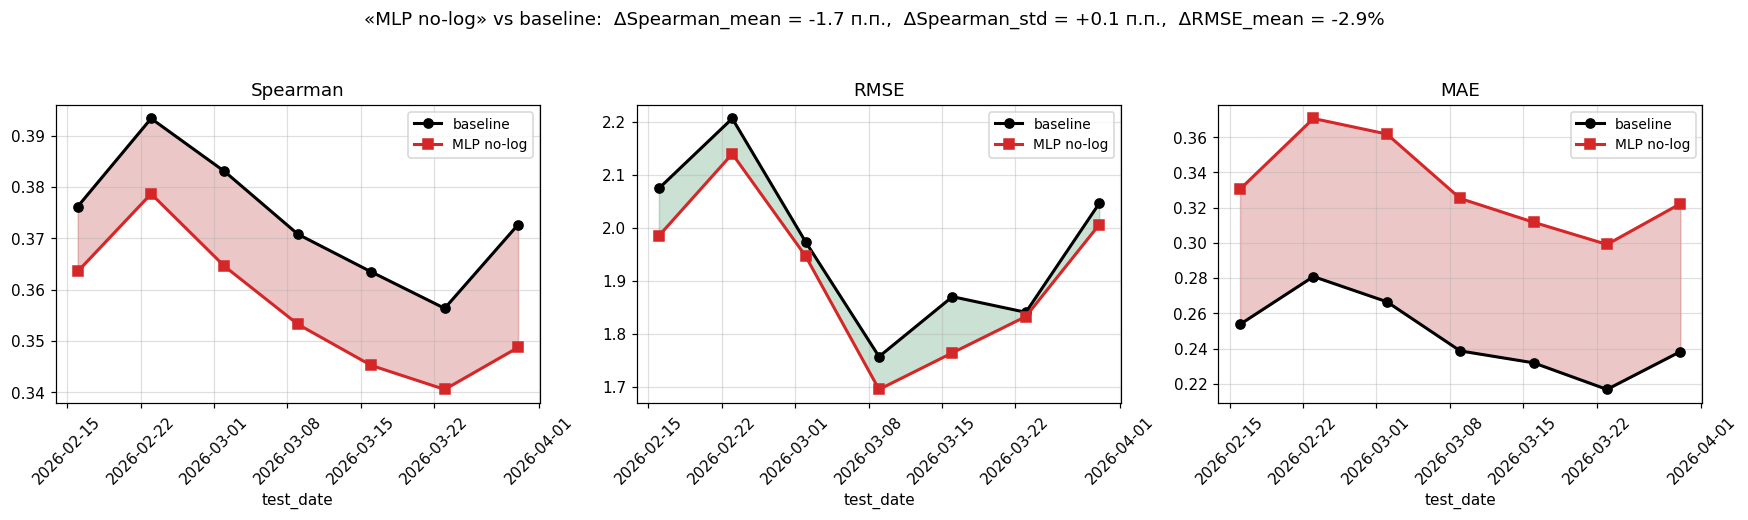


2. MLP с усиленной регуляризацией
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_mlp_regularized.png


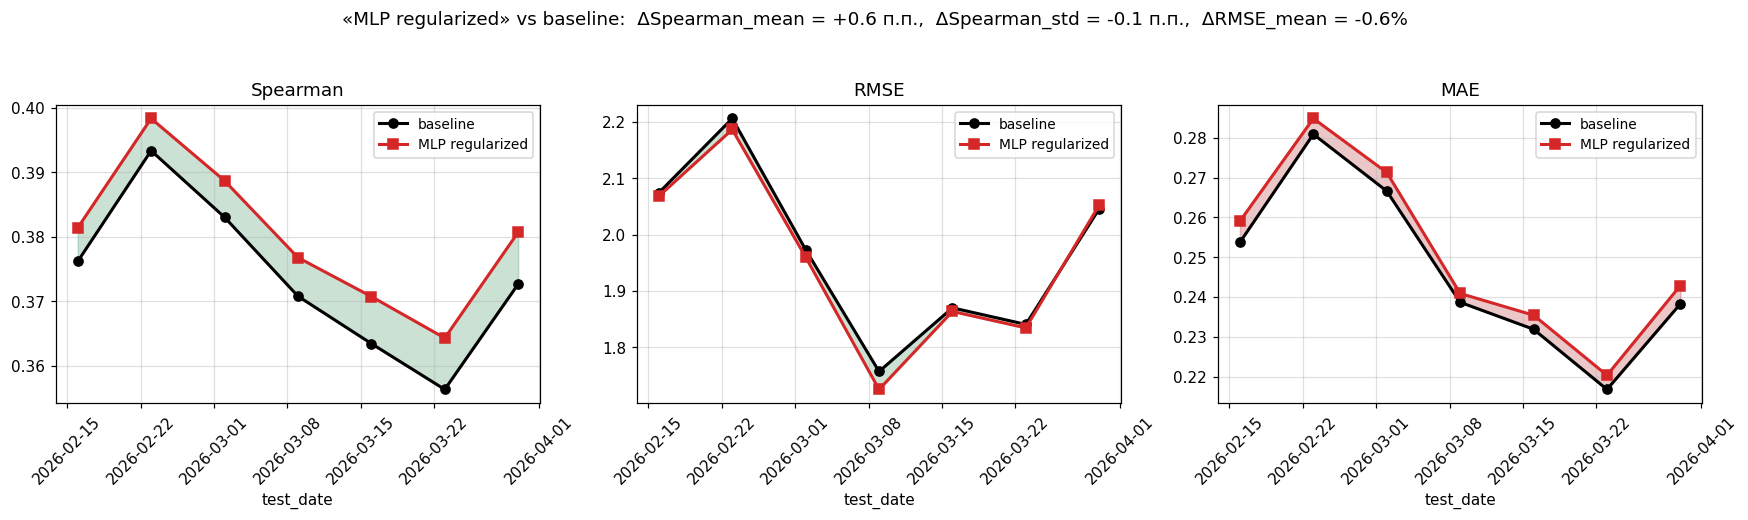


3. MLP без нестабильных признаков
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_mlp_drop_unstable.png


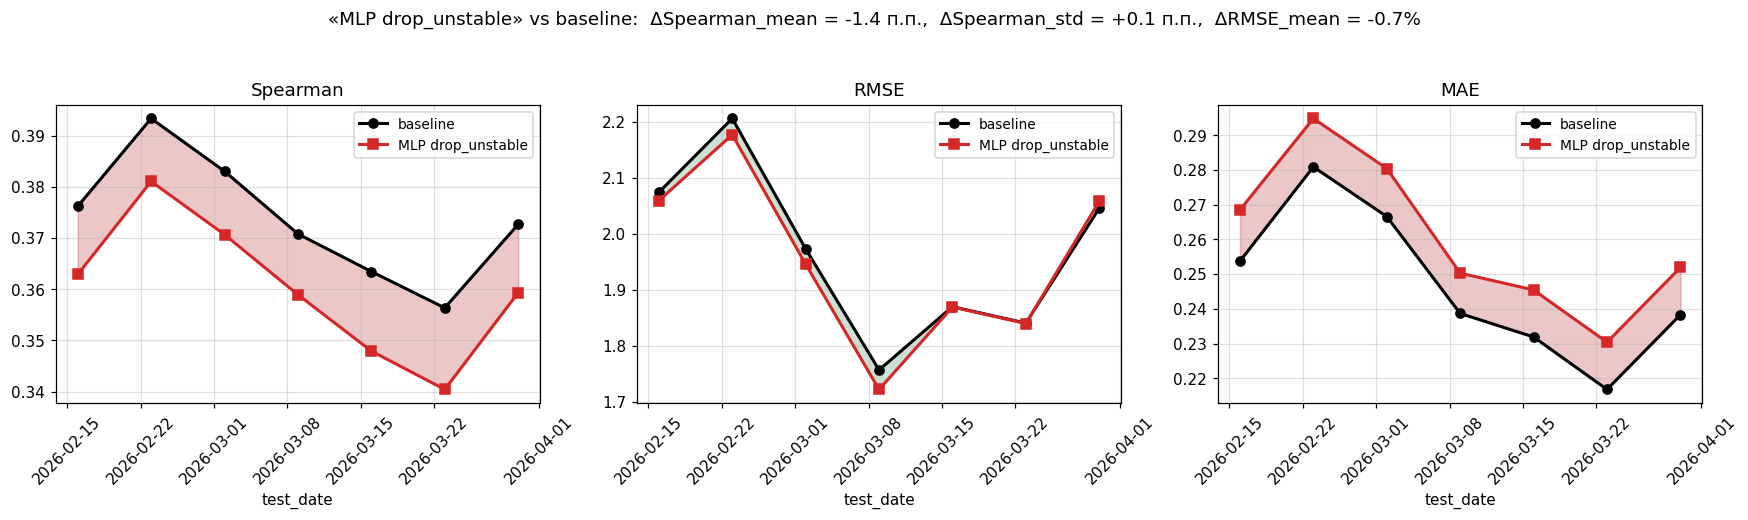


4. MLP two-stage hurdle model
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_mlp_two_stage.png


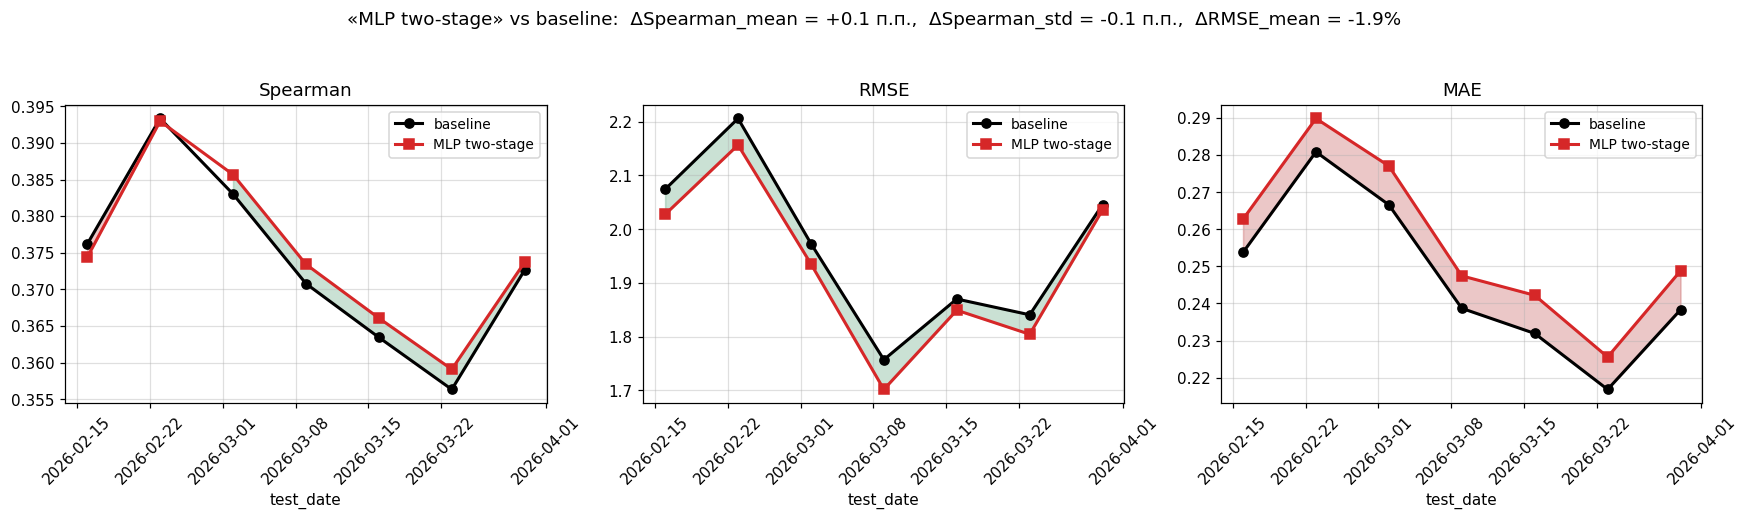


5. MLP sliding window, W=70 дней
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_mlp_sliding_70.png


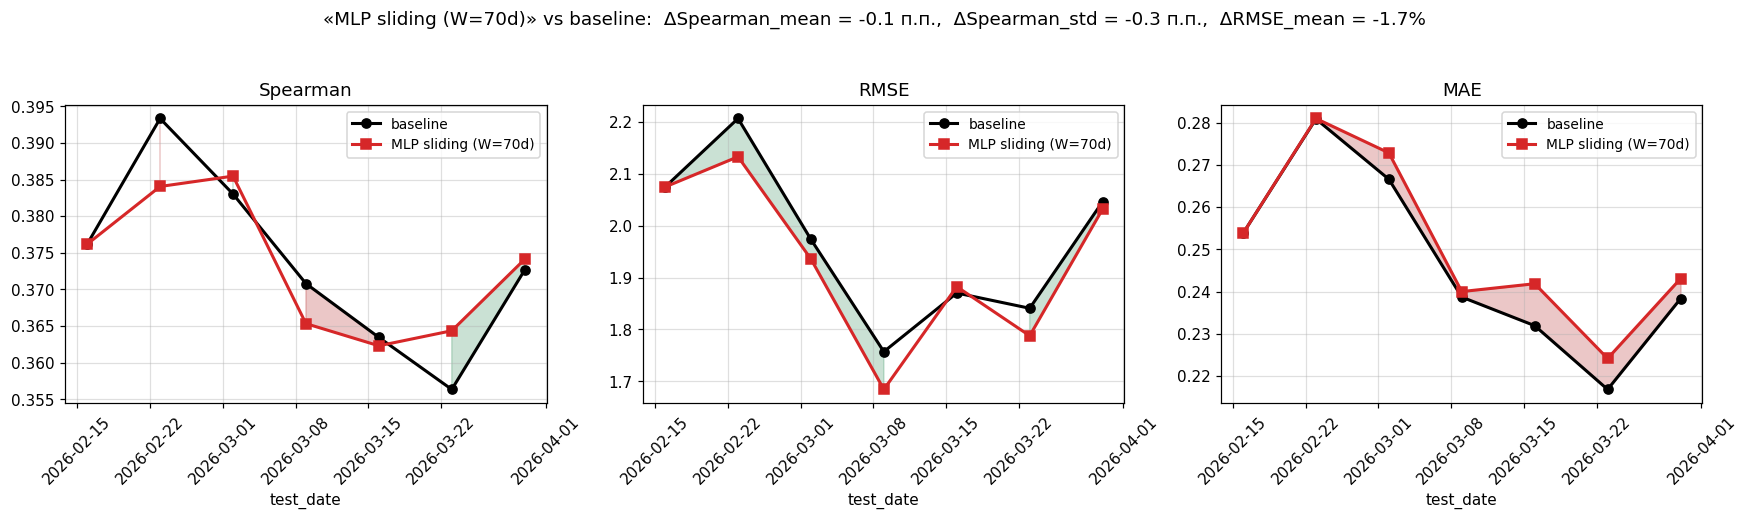

In [23]:
print("MLP extended — 5 экспериментов")

mlp_results = {
    "0. MLP baseline (static, log)": base_mlp
}


print("\n1. MLP без log1p target")

mlp_results["1. MLP no-log"] = fit_static_mlp(
    df=df,
    train_mask=df["snapshot_date"] <= train_end,
    val_dates=val_dates,
    test_dates=test_dates,
    num_cols=cfg["num"],
    low_card_cols=cfg["low"],
    high_card_cols=cfg["high"],
    use_log_target=False,
    hidden_layers=(64, 32),
    max_iter=20,
)

plot_exp_vs_baseline(
    "MLP no-log",
    mlp_results["1. MLP no-log"],
    base_mlp,
    save_name="exp_mlp_no_log.png",
)

print("\n2. MLP с усиленной регуляризацией")

mlp_results["2. MLP regularized"] = fit_static_mlp(
    df=df,
    train_mask=df["snapshot_date"] <= train_end,
    val_dates=val_dates,
    test_dates=test_dates,
    num_cols=cfg["num"],
    low_card_cols=cfg["low"],
    high_card_cols=cfg["high"],
    use_log_target=True,
    hidden_layers=(128, 64),
    max_iter=30,
    alpha=1e-2,
)

plot_exp_vs_baseline(
    "MLP regularized",
    mlp_results["2. MLP regularized"],
    base_mlp,
    save_name="exp_mlp_regularized.png",
)

print("\n3. MLP без нестабильных признаков")

mlp_results["3. MLP drop_unstable"] = fit_static_mlp(
    df=df,
    train_mask=df["snapshot_date"] <= train_end,
    val_dates=val_dates,
    test_dates=test_dates,
    num_cols=stable_cfg["num"],
    low_card_cols=stable_cfg["low"],
    high_card_cols=stable_cfg["high"],
    use_log_target=True,
    hidden_layers=(64, 32),
    max_iter=25,
)

plot_exp_vs_baseline(
    "MLP drop_unstable",
    mlp_results["3. MLP drop_unstable"],
    base_mlp,
    save_name="exp_mlp_drop_unstable.png",
)

print("\n4. MLP two-stage hurdle model")

mlp_results["4. MLP two-stage"] = fit_two_stage_mlp(
    df=df,
    train_mask=df["snapshot_date"] <= train_end,
    val_dates=val_dates,
    test_dates=test_dates,
    num_cols=cfg["num"],
    low_card_cols=cfg["low"],
    high_card_cols=cfg["high"],
)

plot_exp_vs_baseline(
    "MLP two-stage",
    mlp_results["4. MLP two-stage"],
    base_mlp,
    save_name="exp_mlp_two_stage.png",
)

print("\n5. MLP sliding window, W=70 дней")

mlp_results["5. MLP sliding (W=70d)"] = fit_sliding_mlp(
    df=df,
    val_dates=val_dates,
    test_dates=test_dates,
    num_cols=cfg["num"],
    low_card_cols=cfg["low"],
    high_card_cols=cfg["high"],
    train_window_days=70,
    use_log_target=True,
    hidden_layers=(64, 32),
    max_iter=20,
)

plot_exp_vs_baseline(
    "MLP sliding (W=70d)",
    mlp_results["5. MLP sliding (W=70d)"],
    base_mlp,
    save_name="exp_mlp_sliding_70.png",
)


MLP deep-dive — сводка по TEST:
                        model  Spearman_mean  Spearman_std  stability   slope  R2_mean  RMSE_mean  MAE_mean
0. MLP baseline (static, log)         0.3737        0.0113     0.9888 -0.0037   0.2485     1.9668    0.2467
                1. MLP no-log         0.3564        0.0123     0.9879 -0.0050   0.2912     1.9099    0.3316
           2. MLP regularized         0.3801        0.0104     0.9897 -0.0031   0.2569     1.9559    0.2507
         3. MLP drop_unstable         0.3602        0.0125     0.9876 -0.0041   0.2587     1.9533    0.2603
             4. MLP two-stage         0.3751        0.0105     0.9896 -0.0032   0.2762     1.9303    0.2562
       5. MLP sliding (W=70d)         0.3731        0.0088     0.9913 -0.0025   0.2743     1.9327    0.2509
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/mlp_deepdive_compare.png


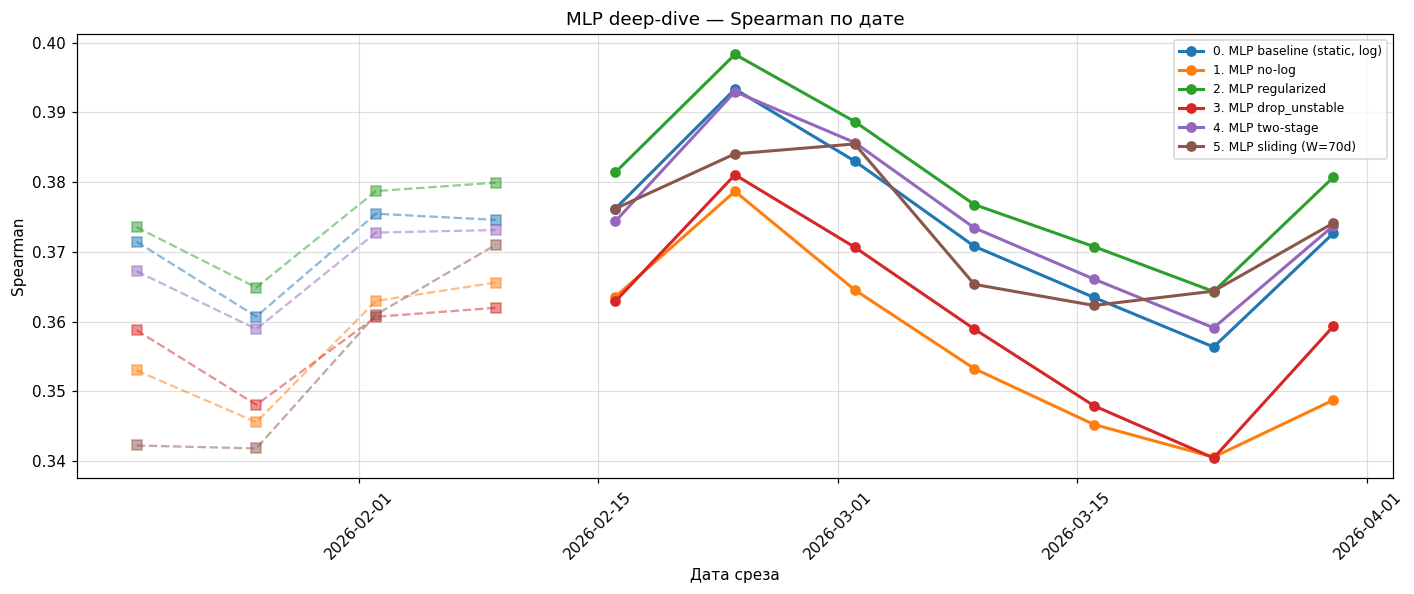

In [24]:
mlp_summary = pd.DataFrame([
    stability_row(model_name, result, "test")
    for model_name, result in mlp_results.items()
    if result is not None and len(result) > 0
])

print("\nMLP deep-dive — сводка по TEST:")
print(mlp_summary.round(4).to_string(index=False))

mlp_summary.to_csv(
    os.path.join(ART_DIR, "mlp_summary.csv"),
    index=False,
)
fig, ax = plt.subplots(figsize=(13, 5.5))
colors = plt.cm.tab10.colors
for i, (model_name, result) in enumerate(mlp_results.items()):
    if result is None or len(result) == 0:
        continue
    color = colors[i % 10]
    val_result = result[result["split"] == "val"].sort_values("test_date")
    test_result = result[result["split"] == "test"].sort_values("test_date")
    if len(val_result) > 0:
        ax.plot(
            val_result["test_date"],
            val_result["Spearman"],
            "s--",
            color=color,
            alpha=0.5,
        )
    if len(test_result) > 0:
        ax.plot(
            test_result["test_date"],
            test_result["Spearman"],
            "o-",
            color=color,
            linewidth=2,
            label=model_name,
        )
ax.set_title("MLP deep-dive — Spearman по дате")
ax.set_xlabel("Дата среза")
ax.set_ylabel("Spearman")
ax.legend(fontsize=8, loc="best")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.4)
save_fig("mlp_deepdive_compare.png")

## 15. Per-model window sweep — ключевое нововведение

Здесь для каждой модели — отдельный sweep по `train_win_days ∈ {28, 42, 56, 70}` в sliding-режиме.

Зачем: разные семейства моделей имеют разную потребность в объёме
обучающих данных. Линейные хорошо обобщают с маленьким окном; нейросетям
типично нужно больше; LightGBM где-то посередине. Подобрать окно
индивидуально — корректнее, чем брать оптимум только LightGBM.

Критерий выбора лучшего окна: среди окон, у которых `Spearman_std`
не более чем в 1.5 раза превышает минимум по строкам, выбираем то, у
которого `Spearman_mean` максимален. Это даёт баланс между качеством и
стабильностью.

Получаем три персональных окна: `BEST_WIN_RIDGE`, `BEST_WIN_LGBM`,
`BEST_WIN_MLP`. Они используются в Части 16.

PER-MODEL WINDOW SWEEP — ОТДЕЛЬНОЕ ОПТИМАЛЬНОЕ ОКНО ДЛЯ КАЖДОЙ МОДЕЛИ

[Ridge log] sweep по окнам [28, 42, 56, 70]
  window = 28 дней
    Spearman_mean=0.3551  std=0.0101  (заняло 52.5s)
  window = 42 дней
    Spearman_mean=0.3571  std=0.0121  (заняло 77.9s)
  window = 56 дней
    Spearman_mean=0.3571  std=0.0132  (заняло 99.8s)
  window = 70 дней
    Spearman_mean=0.3567  std=0.0135  (заняло 109.8s)

Ridge log sweep summary:
         model  Spearman_mean  Spearman_std  stability   slope  R2_mean  RMSE_mean  MAE_mean  window  fit_time_s
Ridge log W=28         0.3551        0.0101     0.9900 -0.0040   0.2081     2.0193    0.2638      28     52.4926
Ridge log W=42         0.3571        0.0121     0.9880 -0.0047   0.2056     2.0225    0.2644      42     77.8890
Ridge log W=56         0.3571        0.0132     0.9870 -0.0050   0.2043     2.0240    0.2657      56     99.8139
Ridge log W=70         0.3567        0.0135     0.9867 -0.0053   0.2039     2.0244    0.2667      70    109.7782

[Lig

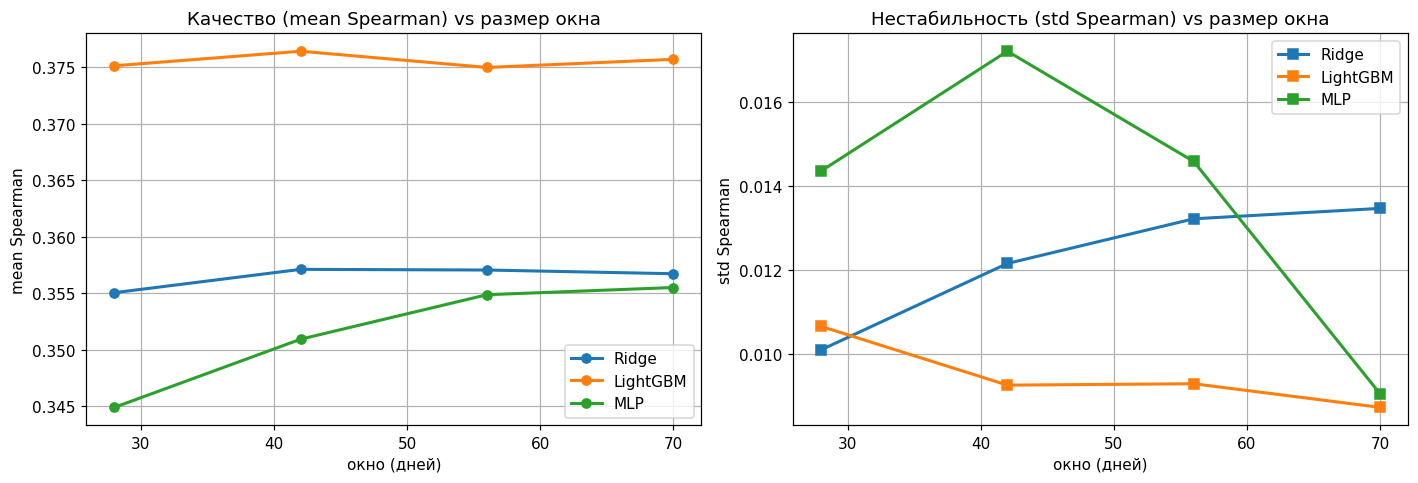


Лучшие окна (per-model):
  Ridge:    42 дн.
  LightGBM: 42 дн.
  MLP:      70 дн.


In [25]:
print("PER-MODEL WINDOW SWEEP — ОТДЕЛЬНОЕ ОПТИМАЛЬНОЕ ОКНО ДЛЯ КАЖДОЙ МОДЕЛИ")
WINDOWS = [28, 42, 56, 70]
sweep_results = {}
sweep_tables = {} 

for mkind, mlabel in [("ridge", "Ridge log"), ("lgbm", "LightGBM"), ("mlp", "MLP")]:
    print(f"\n[{mlabel}] sweep по окнам {WINDOWS}")
    sweep_results[mkind] = {}
    rows = []
    for w in WINDOWS:
        print(f"  window = {w} дней", flush=True)
        t0 = time.time()
        c = temporal_eval(
            df, cfg["num"], cfg["low"], cfg["high"], mkind, train_end, "sliding",
            train_win_days=w, val_dates=val_dates, test_dates=test_dates,
            log_target=True, use_log_num=True, alpha=3.0, lgb_params=lgb_base,
            mlp_hidden=(32,), mlp_epochs=15,
        )
        sweep_results[mkind][w] = c
        s = stability_row(f"{mlabel} W={w}", c, "test")
        s["window"] = w
        s["fit_time_s"] = time.time() - t0
        rows.append(s)
        print(f"    Spearman_mean={s['Spearman_mean']:.4f}  std={s['Spearman_std']:.4f}  "
              f"(заняло {s['fit_time_s']:.1f}s)")
    sweep_tables[mkind] = pd.DataFrame(rows)
    sweep_tables[mkind].to_csv(os.path.join(ART_DIR, f"sweep_{mkind}.csv"), index=False)
    print(f"\n{mlabel} sweep summary:")
    print(sweep_tables[mkind].round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for mkind, mlabel, col in zip(["ridge", "lgbm", "mlp"], ["Ridge", "LightGBM", "MLP"],
                                ["tab:blue", "tab:orange", "tab:green"]):
    t = sweep_tables[mkind]
    axes[0].plot(t["window"], t["Spearman_mean"], "o-", color=col, label=mlabel, linewidth=2)
    axes[1].plot(t["window"], t["Spearman_std"], "s-", color=col, label=mlabel, linewidth=2)
axes[0].set_title("Качество (mean Spearman) vs размер окна")
axes[0].set_xlabel("окно (дней)"); axes[0].set_ylabel("mean Spearman"); axes[0].legend()
axes[1].set_title("Нестабильность (std Spearman) vs размер окна")
axes[1].set_xlabel("окно (дней)"); axes[1].set_ylabel("std Spearman"); axes[1].legend()
save_fig("window_sweep_per_model.png")

def pick_best_window(table):
    min_std = table["Spearman_std"].min()
    cand = table[table["Spearman_std"] <= 1.5 * min_std]
    if cand.empty:
        cand = table
    return int(cand.sort_values("Spearman_mean", ascending=False).iloc[0]["window"])


BEST_WIN_RIDGE = pick_best_window(sweep_tables["ridge"])
BEST_WIN_LGBM = pick_best_window(sweep_tables["lgbm"])
BEST_WIN_MLP = pick_best_window(sweep_tables["mlp"])
print(f"\nЛучшие окна (per-model):")
print(f"  Ridge:    {BEST_WIN_RIDGE} дн.")
print(f"  LightGBM: {BEST_WIN_LGBM} дн.")
print(f"  MLP:      {BEST_WIN_MLP} дн.")

## 16. Финальное 3-way сравнение моделей и режимов

Сравниваем три модели в двух режимах:

- **STATIC** — берём кривые из Baselines (Части 7-9) — Ridge / LGBM / MLP,
  обученные один раз на train.
- **SLIDING** — каждая модель на своём `BEST_WIN_*` (из Части 15).

Это и есть честное сравнение трёх семейств в одной системе координат:
оптимальное окно подобрано индивидуально, метрики на тех же 7 test-датах.

Pareto-scatter `mean Spearman × 1/(1+std)`:
- кружки = static, треугольники = sliding;
- цвет = тип модели;
- идеал — правый верхний угол.

ФИНАЛЬНОЕ 3-WAY СРАВНЕНИЕ (на персональных окнах)
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/three_static_spearman.png


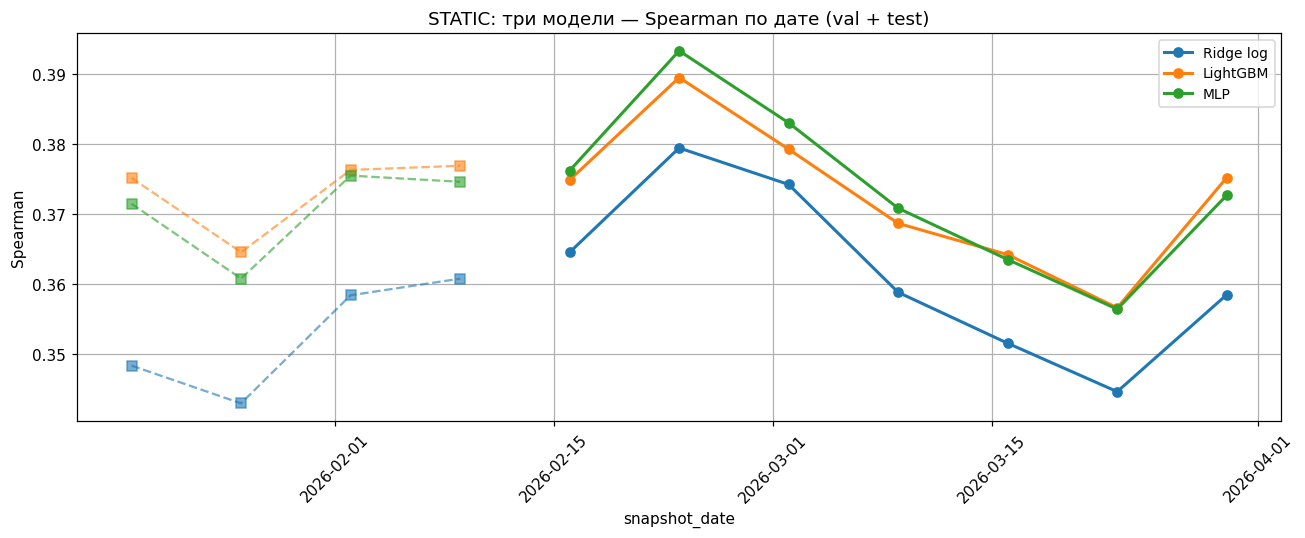

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/three_sliding_spearman.png


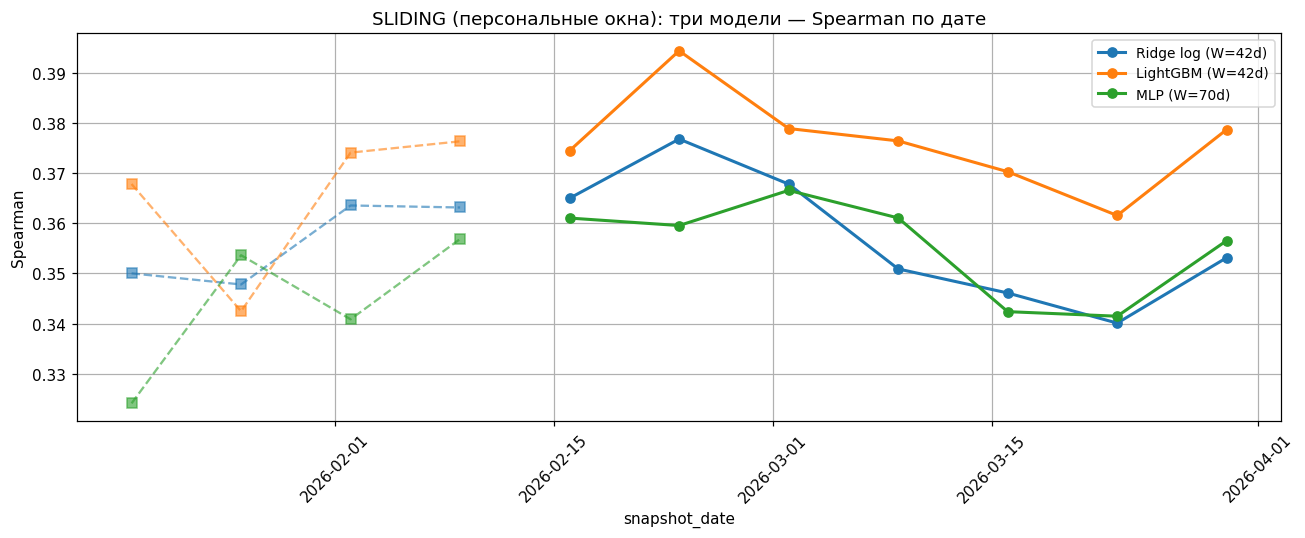


3-way сводка:
                      model  Spearman_mean  Spearman_std  stability   slope  R2_mean  RMSE_mean  MAE_mean    mode
         Ridge log / static         0.3616        0.0113     0.9888 -0.0040   0.2001     2.0291    0.2659  static
          LightGBM / static         0.3726        0.0099     0.9902 -0.0029   0.2846     1.9189    0.2488  static
               MLP / static         0.3737        0.0113     0.9888 -0.0037   0.2485     1.9668    0.2467  static
Ridge log (W=42d) / sliding         0.3571        0.0121     0.9880 -0.0047   0.2056     2.0225    0.2644 sliding
 LightGBM (W=42d) / sliding         0.3764        0.0092     0.9908 -0.0022   0.2891     1.9133    0.2502 sliding
      MLP (W=70d) / sliding         0.3555        0.0090     0.9910 -0.0026   0.2769     1.9293    0.2542 sliding
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/three_way_pareto.png


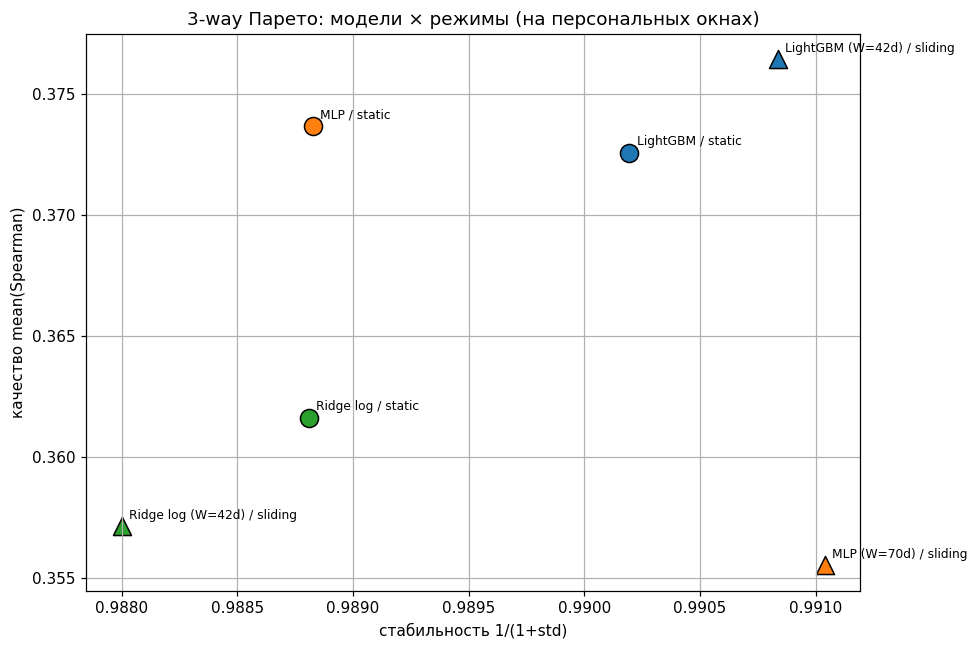

In [26]:
print("ФИНАЛЬНОЕ 3-WAY СРАВНЕНИЕ (на персональных окнах)")
three_static = {"Ridge log": base_ridge, "LightGBM": base_lgbm, "MLP": base_mlp}
three_sliding = {
    f"Ridge log (W={BEST_WIN_RIDGE}d)": sweep_results["ridge"][BEST_WIN_RIDGE],
    f"LightGBM (W={BEST_WIN_LGBM}d)": sweep_results["lgbm"][BEST_WIN_LGBM],
    f"MLP (W={BEST_WIN_MLP}d)": sweep_results["mlp"][BEST_WIN_MLP],
}

plot_three_curves(three_static, "Spearman",
                  "STATIC: три модели — Spearman по дате (val + test)")
save_fig("three_static_spearman.png")
plot_three_curves(three_sliding, "Spearman",
                  f"SLIDING (персональные окна): три модели — Spearman по дате")
save_fig("three_sliding_spearman.png")

rows = []
for name, c in three_static.items():
    r = stability_row(name + " / static", c, "test")
    r["mode"] = "static"
    rows.append(r)
for name, c in three_sliding.items():
    r = stability_row(name + " / sliding", c, "test")
    r["mode"] = "sliding"
    rows.append(r)
three_summary = pd.DataFrame(rows)
print("\n3-way сводка:")
print(three_summary.round(4).to_string(index=False))
three_summary.to_csv(os.path.join(ART_DIR, "three_way_summary.csv"), index=False)

fig, ax = plt.subplots(figsize=(9, 6))
markers = {"static": "o", "sliding": "^"}
model_short = sorted({r["model"].split(" /")[0].split(" (")[0] for r in rows})
colors_d = {m: plt.cm.tab10(i) for i, m in enumerate(model_short)}
for _, r in three_summary.iterrows():
    short = r["model"].split(" /")[0].split(" (")[0]
    ax.scatter(r["stability"], r["Spearman_mean"], s=140,
               marker=markers[r["mode"]], color=colors_d[short], edgecolor="black")
    ax.annotate(r["model"], (r["stability"], r["Spearman_mean"]),
                xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set_xlabel("стабильность 1/(1+std)")
ax.set_ylabel("качество mean(Spearman)")
ax.set_title("3-way Парето: модели × режимы (на персональных окнах)")
save_fig("three_way_pareto.png")

## 17. BASELINE vs EXTENDED наборы признаков

Помогает ли расширенный блок `ml_*`-признаков стабильности, или, наоборот,
увеличивает экспозицию к дрейфу?

Сравниваем Ridge и LightGBM на двух наборах фич:
- `BASELINE` — ~21 числовой признак (playtime/events/sessions);
- `EXTENDED` — `BASELINE` + блок `ml_init_*` / `ml_snap_*` + `was_nan` (~140).

MLP пропускаем — это не критично для этой оси и сильно ускоряет прогон.

BASELINE vs EXTENDED НАБОРЫ ПРИЗНАКОВ

[BASELINE]
  Ridge
    Spearman_mean=0.3575
  LightGBM
    Spearman_mean=0.3785

[EXTENDED]
  Ridge
    Spearman_mean=0.3616
  LightGBM
    Spearman_mean=0.3726

Сравнение наборов признаков:
   model  Spearman_mean  Spearman_std  stability   slope  R2_mean  RMSE_mean  MAE_mean  featset
   Ridge         0.3575        0.0107     0.9894 -0.0033   0.1909     2.0408    0.2679 BASELINE
LightGBM         0.3785        0.0113     0.9889 -0.0035   0.2518     1.9624    0.2584 BASELINE
   Ridge         0.3616        0.0113     0.9888 -0.0040   0.2001     2.0291    0.2659 EXTENDED
LightGBM         0.3726        0.0099     0.9902 -0.0029   0.2846     1.9189    0.2488 EXTENDED
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/baseline_vs_extended.png


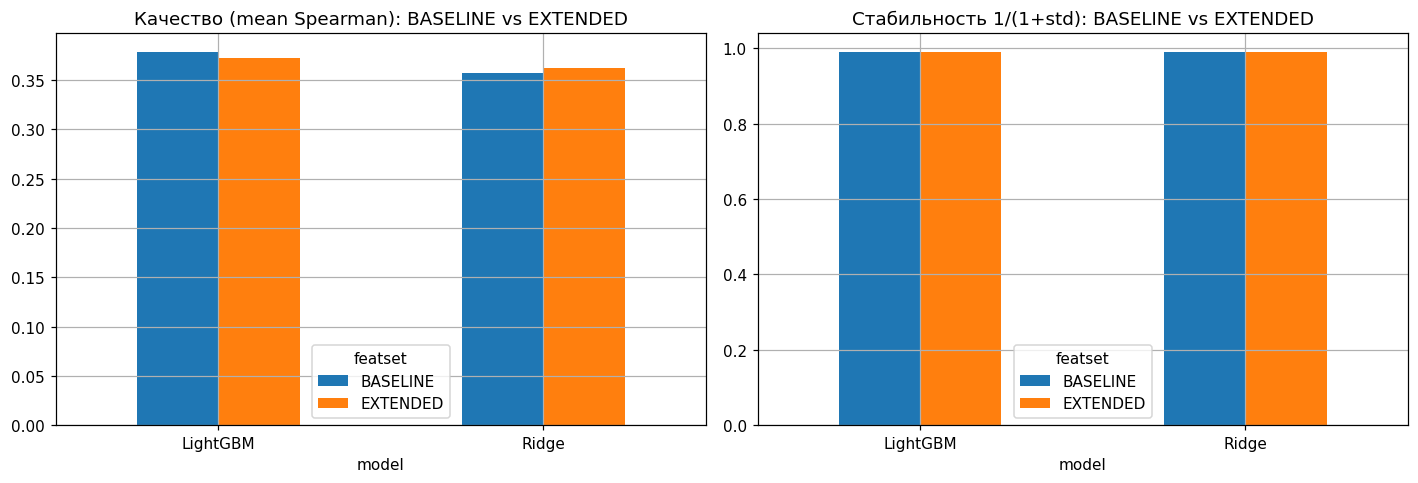

In [27]:
print("BASELINE vs EXTENDED НАБОРЫ ПРИЗНАКОВ")
fs_rows = []
for fs_name in ("BASELINE", "EXTENDED"):
    cfg_fs = FEATS[fs_name]
    print(f"\n[{fs_name}]")
    print("  Ridge")
    c_ridge = temporal_eval(
        df, cfg_fs["num"], cfg_fs["low"], cfg_fs["high"], "ridge", train_end, "static",
        val_dates=val_dates, test_dates=test_dates,
        log_target=True, use_log_num=True, alpha=3.0,
    )
    s = stability_row(f"Ridge ({fs_name})", c_ridge, "test"); s["featset"] = fs_name; s["model"] = "Ridge"
    fs_rows.append(s)
    print(f"    Spearman_mean={s['Spearman_mean']:.4f}")

    print("  LightGBM")
    if fs_name == "EXTENDED":
        s = stability_row(f"LightGBM ({fs_name})", base_lgbm, "test"); s["featset"] = fs_name; s["model"] = "LightGBM"
    else:
        c_lgb = temporal_eval(
            df, cfg_fs["num"], cfg_fs["low"], cfg_fs["high"], "lgbm", train_end, "static",
            val_dates=val_dates, test_dates=test_dates,
            log_target=True, lgb_params=lgb_base,
        )
        s = stability_row(f"LightGBM ({fs_name})", c_lgb, "test"); s["featset"] = fs_name; s["model"] = "LightGBM"
    fs_rows.append(s)
    print(f"    Spearman_mean={s['Spearman_mean']:.4f}")

fs_cmp = pd.DataFrame(fs_rows)
print("\nСравнение наборов признаков:")
print(fs_cmp.round(4).to_string(index=False))
fs_cmp.to_csv(os.path.join(ART_DIR, "baseline_vs_extended.csv"), index=False)

piv_q = fs_cmp.pivot(index="model", columns="featset", values="Spearman_mean")
piv_s = fs_cmp.pivot(index="model", columns="featset", values="stability")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
piv_q.plot.bar(ax=axes[0], rot=0)
axes[0].set_title("Качество (mean Spearman): BASELINE vs EXTENDED")
piv_s.plot.bar(ax=axes[1], rot=0)
axes[1].set_title("Стабильность 1/(1+std): BASELINE vs EXTENDED")
save_fig("baseline_vs_extended.png")

## 18. Финальный Парето + выбор best-модели

Собираем все эксперименты + baselines + sliding на одних осях
`mean Spearman × 1/(1+std)`.

**Критерий выбора best:**
1. **Pareto-доминатор baseline LightGBM** — модель, у которой
   `Spearman_mean ≥ baseline` И `Spearman_std ≤ baseline`. Это «бесплатное»
   улучшение по обоим осям; всегда предпочтительно.
2. Если таких нет — берём топ по `Spearman_mean` среди моделей, у которых
   `Spearman_std ≤ 1.5 × baseline_std` (бюджет нестабильности).

Главный график «до/после» — baseline LightGBM vs выбранная best-модель,
Spearman по test-датам с заливкой:
- зелёная = best лучше baseline на этой дате;
- красная = best хуже.

Если best — Pareto-доминатор, заливка должна быть преимущественно зелёной.

ФИНАЛЬНЫЙ PARETO И ВЫБОР МОДЕЛИ
                         model  Spearman_mean  Spearman_std  stability   slope  R2_mean  RMSE_mean  MAE_mean
         LGBM-LGBM quantile-50         0.5139        0.0106     0.9895 -0.0044   0.2165     2.0082    0.2302
               LGBM-LGBM huber         0.3834        0.0114     0.9888 -0.0036   0.1915     2.0400    0.2511
         LGBM-LGBM regularized         0.3782        0.0114     0.9888 -0.0037   0.2699     1.9385    0.2518
       LGBM-LGBM sliding (42d)         0.3764        0.0092     0.9908 -0.0022   0.2891     1.9133    0.2502
      LightGBM-sliding (W=42d)         0.3764        0.0092     0.9908 -0.0022   0.2891     1.9133    0.2502
           LGBM-LGBM two-stage         0.3751        0.0133     0.9869 -0.0046   0.3013     1.8964    0.2595
         MLP-baseline (static)         0.3737        0.0113     0.9888 -0.0037   0.2485     1.9668    0.2467
   LGBM-baseline (static, log)         0.3726        0.0099     0.9902 -0.0029   0.2846     1.91

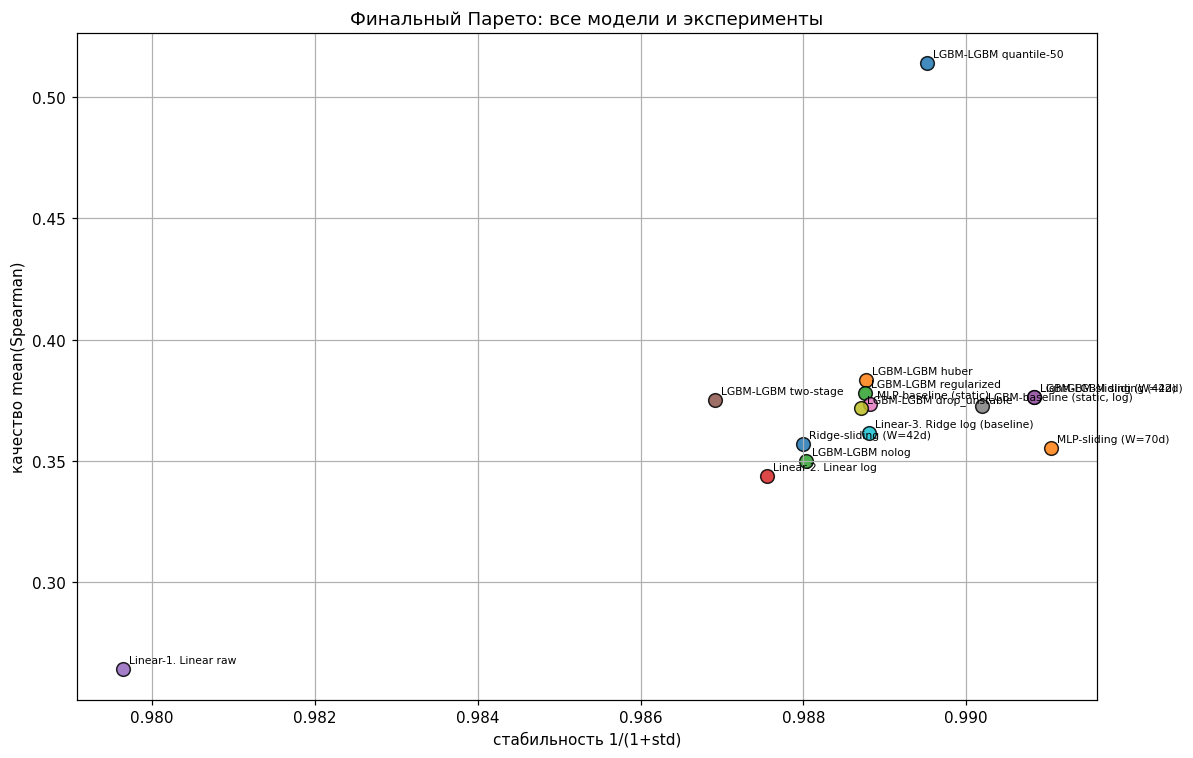


Pareto-доминаторы baseline: 2
ВЫБРАН: LGBM-LGBM sliding (42d)
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/final_baseline_vs_best.png


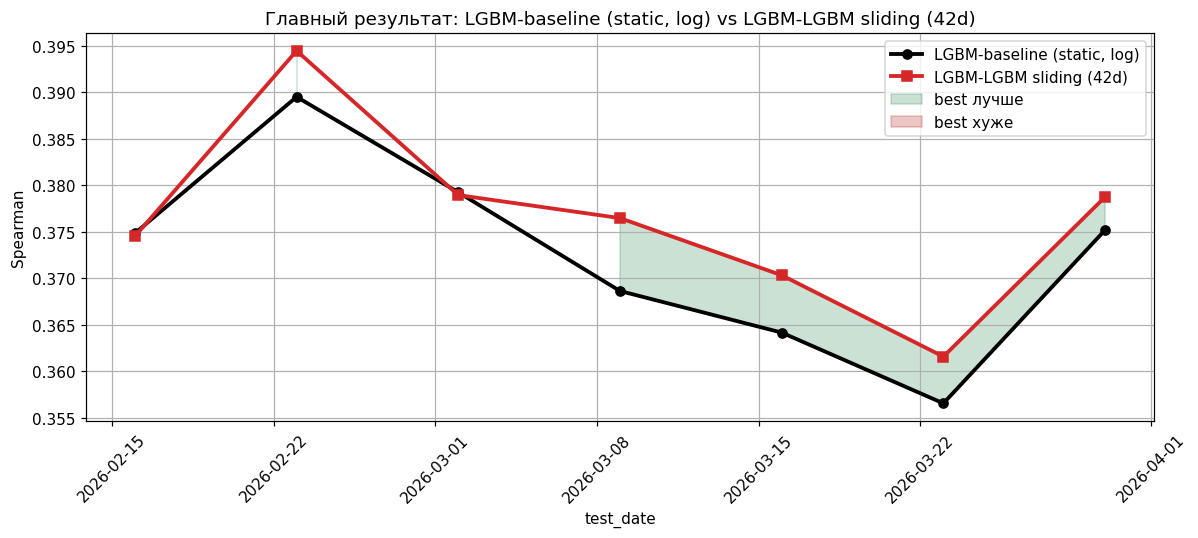

In [29]:
print("ФИНАЛЬНЫЙ PARETO И ВЫБОР МОДЕЛИ")

all_curves = {}

all_curves.update({f"Linear-{k}": v for k, v in linear_curves.items()})
all_curves.update({f"LGBM-{k}": v for k, v in lgbm_curves.items()})

all_curves["MLP-baseline (static)"] = base_mlp

all_curves[f"Ridge-sliding (W={BEST_WIN_RIDGE}d)"] = sweep_results["ridge"][BEST_WIN_RIDGE]
all_curves[f"LightGBM-sliding (W={BEST_WIN_LGBM}d)"] = sweep_results["lgbm"][BEST_WIN_LGBM]
all_curves[f"MLP-sliding (W={BEST_WIN_MLP}d)"] = sweep_results["mlp"][BEST_WIN_MLP]


final_summary = pd.DataFrame([
    stability_row(n, c, "test")
    for n, c in all_curves.items()
    if c is not None and len(c) > 0
])

final_summary = final_summary.sort_values(
    "Spearman_mean",
    ascending=False
).reset_index(drop=True)

print(final_summary.round(4).to_string(index=False))

final_summary.to_csv(
    os.path.join(ART_DIR, "final_summary.csv"),
    index=False
)


fig, ax = plt.subplots(figsize=(11, 7))

for _, r in final_summary.iterrows():
    ax.scatter(
        r["stability"],
        r["Spearman_mean"],
        s=80,
        edgecolor="black",
        alpha=0.85
    )

    ax.annotate(
        r["model"],
        (r["stability"], r["Spearman_mean"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7
    )

ax.set_xlabel("стабильность 1/(1+std)")
ax.set_ylabel("качество mean(Spearman)")
ax.set_title("Финальный Парето: все модели и эксперименты")

save_fig("final_pareto.png")


base_candidates = final_summary[
    final_summary["model"].str.contains("baseline", case=False, na=False) &
    final_summary["model"].str.contains("LGBM|LightGBM", case=False, regex=True, na=False)
]

if base_candidates.empty:
    print("\nНе найден baseline LightGBM. Доступные модели:")
    print(final_summary["model"].tolist())
    raise ValueError("Baseline LightGBM не найден в final_summary")

base_row = base_candidates.iloc[0]

base_model_name = base_row["model"]
base_curve = all_curves[base_model_name]

base_sp_mean = base_row["Spearman_mean"]
base_sp_std = base_row["Spearman_std"]


dominators = final_summary[
    (final_summary["Spearman_mean"] >= base_sp_mean) &
    (final_summary["Spearman_std"] <= base_sp_std) &
    (final_summary["model"] != base_model_name)
]

if not dominators.empty:
    best = dominators.sort_values(
        "Spearman_mean",
        ascending=False
    ).iloc[0]

    print(f"\nPareto-доминаторы baseline: {len(dominators)}")
    print(f"ВЫБРАН: {best['model']}")

else:
    cand = final_summary[
        final_summary["Spearman_std"] <= 1.5 * base_sp_std
    ]

    if cand.empty:
        cand = final_summary

    best = cand.sort_values(
        "Spearman_mean",
        ascending=False
    ).iloc[0]

    print(f"\nPareto-доминаторов нет. ВЫБРАН лучший в бюджете std: {best['model']}")


best_curve = all_curves[best["model"]]

bt = base_curve[base_curve["split"] == "test"].sort_values("test_date")
et = best_curve[best_curve["split"] == "test"].sort_values("test_date")

merged = bt[["test_date", "Spearman"]].merge(
    et[["test_date", "Spearman"]],
    on="test_date",
    suffixes=("_base", "_best")
)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    merged["test_date"],
    merged["Spearman_base"],
    "o-",
    color="black",
    linewidth=2.5,
    label=base_model_name
)

ax.plot(
    merged["test_date"],
    merged["Spearman_best"],
    "s-",
    color="tab:red",
    linewidth=2.5,
    label=best["model"]
)

ax.fill_between(
    merged["test_date"],
    merged["Spearman_base"].values,
    merged["Spearman_best"].values,
    where=merged["Spearman_best"].values >= merged["Spearman_base"].values,
    alpha=0.25,
    color="seagreen",
    label="best лучше"
)

ax.fill_between(
    merged["test_date"],
    merged["Spearman_base"].values,
    merged["Spearman_best"].values,
    where=merged["Spearman_best"].values < merged["Spearman_base"].values,
    alpha=0.25,
    color="firebrick",
    label="best хуже"
)

ax.set_title(f"Главный результат: {base_model_name} vs {best['model']}")
ax.set_xlabel("test_date")
ax.set_ylabel("Spearman")
ax.legend()
ax.tick_params(axis="x", rotation=45)

save_fig("final_baseline_vs_best.png")

## Итог


In [30]:
print("ИТОГ")
print(f"Best: {best['model']}")
print(f"  Spearman_mean = {best['Spearman_mean']:.4f}  (baseline {base_sp_mean:.4f})")
print(f"  Spearman_std  = {best['Spearman_std']:.4f}  (baseline {base_sp_std:.4f})")
print(f"  stability     = {best['stability']:.4f}  (baseline {base_row['stability']:.4f})")
print(f"Per-model best windows: Ridge={BEST_WIN_RIDGE}d, LGBM={BEST_WIN_LGBM}d, MLP={BEST_WIN_MLP}d")
print(f"Adversarial AUC: {adv_auc:.4f}")

ИТОГ
Best: LGBM-LGBM sliding (42d)
  Spearman_mean = 0.3764  (baseline 0.3726)
  Spearman_std  = 0.0092  (baseline 0.0099)
  stability     = 0.9908  (baseline 0.9902)
Per-model best windows: Ridge=42d, LGBM=42d, MLP=70d
Adversarial AUC: 0.9733
